## Block 1 · Setup, configuration & utilities


In [1]:
!pip install transformers accelerate bitsandbytes scipy jiwer -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 96.0 MB/s eta 0:00:00


In [2]:
# ============================================================================
# SETUP, IMPORTS & UTILS
# ============================================================================

import os
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import random
import editdistance
import jiwer
from scipy.ndimage import gaussian_filter1d

try:
    import kagglehub
except ImportError:
    kagglehub = None


def resolve_competition_path(local_path, competition_slug):
    """Use the local Kaggle mount if present, otherwise fetch via kagglehub.
    Removes the hard dependency on one specific mount path/environment."""
    if os.path.exists(local_path):
        return local_path
    if kagglehub is not None:
        return os.path.join(kagglehub.competition_download(competition_slug),
                             "t15_copyTask_neuralData/hdf5_data_final")
    raise FileNotFoundError(f"{local_path} not found and kagglehub unavailable.")


# 40-way phoneme inventory used by the Brain-to-Text baseline (index 0 = CTC blank,
# last entry = word-boundary/silence). These IDs are exactly what's already stored
# in each trial's `seq_class_ids` inside the hdf5 files, so we decode phonemes
# directly instead of building a character vocabulary from the raw sentence text.
# This is the single biggest accuracy lever available here: neural activity in this
# dataset aligns to articulatory/phoneme structure far more cleanly than to letters,
# and phoneme CTC + lexicon-constrained decoding is what the strongest solutions on
# this benchmark use.
PHONEME_VOCAB = [
    'BLANK', 'AA', 'AE', 'AH', 'AO', 'AW', 'AY', 'B', 'CH', 'D', 'DH',
    'EH', 'ER', 'EY', 'F', 'G', 'HH', 'IH', 'IY', 'JH', 'K', 'L', 'M', 'N',
    'NG', 'OW', 'OY', 'P', 'R', 'S', 'SH', 'T', 'TH', 'UH', 'UW', 'V', 'W',
    'Y', 'Z', 'ZH', ' | ',
]

CONFIG = {
    'data_dir': resolve_competition_path(
        '/kaggle/input/competitions/brain-to-text-25/t15_copyTask_neuralData/hdf5_data_final',
        'brain-to-text-25',
    ),
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'batch_size': 16,
    'num_epochs': 82,

    # Model architecture
    'd_model': 384,
    'n_heads': 6,
    'n_layers': 4,
    'd_ff': 1536,
    'patch_size': 3,
    'lstm_hidden': 256,
    'lstm_layers': 2,
    'n_classes': len(PHONEME_VOCAB),   # was a small character vocab built from raw text

    # Regularization & Adaptation
    'dropout': 0.4,
    'head_dim': 256,
    'attn_dropout': 0.5,
    'drop_path_rate': 0.2,
    'smooth_kernel_std': 2.0,
    'smooth_kernel_size': 100,
    'drift_lambda': 0.01,

    # Optimizer
    'learning_rate': 5e-4,
    'weight_decay': 1e-4,
    'use_augmentation': True,

    # Memory / stability
    'use_amp': True,          # NEW: mixed precision -> lower memory, room for bigger batches
    'grad_clip': 5.0,

    # Checkpointing - no hardcoded personal Kaggle model path. Leave None to train
    # from scratch, or point it at your own checkpoint to resume.
    'resume_from_checkpoint': None,
    'checkpoint_dir': '/kaggle/working',
}

# ============================================================================
# SKIP_TRAINING: reuse an already-trained checkpoint instead of training again
# ============================================================================
# Set SKIP_TRAINING = True once you have best_model.pt (and ideally
# swa_model.pt + norm_stats.pt) saved permanently as a Kaggle Dataset - e.g.
# from a previous Save Version run's Output ("+ New Dataset" on that Output
# tab). Attach that dataset to this notebook via '+ Add Input', then put its
# slug below. With this on, the training-driver cell and the early
# (pre-checkpoint-reload) eval plots skip entirely instead of reloading the
# full 45-session train split just to throw the result away - that reload
# alone is what was taking several minutes to hours for nothing.
SKIP_TRAINING = True
PRETRAINED_CKPT_DATASET = 'shohan3125/brain-to-text-checkpoint'

os.makedirs(CONFIG['checkpoint_dir'], exist_ok=True)

# Defined here (unconditionally, at the very top) instead of only inside the
# Block 4b eval-plot cell - those are SKIPPED entirely when SKIP_TRAINING=True,
# which used to leave `figures_dir` completely undefined and crash every plot
# cell in the Block 5 validation pipeline with a NameError, even though nothing
# about that crash had anything to do with plotting logic itself.
figures_dir = os.path.join(CONFIG['checkpoint_dir'], 'figures')
os.makedirs(figures_dir, exist_ok=True)

print(f"Device: {CONFIG['device']}")
print(f"PyTorch version: {torch.__version__}")
print(f"SKIP_TRAINING: {SKIP_TRAINING}")
print(f"Phoneme classes (incl. blank): {CONFIG['n_classes']}")

# --- Helper: Stochastic Depth ---
def drop_path(x, drop_prob: float = 0., training: bool = False, scale_by_keep: bool = True):
    if drop_prob == 0. or not training:
        return x
    keep_prob = 1 - drop_prob
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    random_tensor = x.new_empty(shape).bernoulli_(keep_prob)
    if keep_prob > 0.0 and scale_by_keep:
        random_tensor.div_(keep_prob)
    return x * random_tensor

# --- Helper: Global Session Mapper ---
def get_session2idx(data_dir):
    """Scans data directory to find all unique sessions chronologically."""
    from glob import glob
    paths = glob(f'{data_dir}/**/data_*.hdf5', recursive=True)
    sessions = sorted(list(set([Path(p).parent.name for p in paths])))
    return {s: i for i, s in enumerate(sessions)}


# --- Helper: Kaggle dataset resolver (avoids the kagglehub non-interactive error) ---
def resolve_kaggle_dataset(slug, local_dirname=None):
    """Prefer an already-attached Kaggle dataset under /kaggle/input (works in
    BOTH interactive editing AND non-interactive 'Save & Run All' / submission
    runs), and only fall back to kagglehub.dataset_download() - which only
    works interactively - when nothing is found locally.

    kagglehub.dataset_download() tries to attach the dataset to the current
    session on first use. That works while you're clicking through cells
    yourself, but Kaggle refuses to attach a *new* dataset during a
    non-interactive commit/submission run ('New Datasets cannot be attached
    in non-interactive sessions'), which is exactly the run that matters for
    scoring. Fix: attach the dataset once via '+ Add Input' in the notebook
    editor.

    Manually-attached datasets don't always land at the "clean"
    /kaggle/input/<name> path - depending on how they were added they can be
    nested under /kaggle/input/datasets/<owner>/<name>/... instead - so this
    checks both layouts, then falls back to a recursive search by folder name
    (handles version-suffix mismatches like ".../foo" vs ".../foo-updated-v3"
    too), before finally trying kagglehub as a last resort.
    """
    if local_dirname is None:
        local_dirname = slug.split('/')[-1]
    owner = slug.split('/')[0] if '/' in slug else None

    candidates = [f'/kaggle/input/{local_dirname}']
    if owner:
        candidates.append(f'/kaggle/input/datasets/{owner}/{local_dirname}')

    if os.path.isdir('/kaggle/input'):
        for root, dirs, _ in os.walk('/kaggle/input'):
            for d in dirs:
                if local_dirname.lower() in d.lower() or d.lower() in local_dirname.lower():
                    candidates.append(os.path.join(root, d))

    for path in candidates:
        if os.path.exists(path):
            return path
    try:
        import kagglehub
        return kagglehub.dataset_download(slug)
    except Exception as e:
        raise FileNotFoundError(
            f"Could not find dataset '{slug}' under /kaggle/input (tried "
            f"{candidates}) and kagglehub.dataset_download() also failed: {e}\n"
            f"Fix: open this notebook in the editor, click '+ Add Input' "
            f"(top-right), search for '{slug.split('/')[-1]}', attach it, "
            f"then re-run / Save & Run All."
        ) from e


def find_file(root_dir, filename_pattern):
    """Recursively find a file under root_dir matching filename_pattern
    (e.g. '*.bin' or 'lexicon.txt'). Used because attached-dataset internal
    folder/file layout can vary slightly between dataset versions - safer
    than hardcoding one exact relative path."""
    from glob import glob
    matches = sorted(glob(os.path.join(root_dir, '**', filename_pattern), recursive=True))
    if not matches:
        raise FileNotFoundError(f"No file matching '{filename_pattern}' found under {root_dir}")
    return matches[0]


Device: cuda
PyTorch version: 2.10.0+cu128
SKIP_TRAINING: True
Phoneme classes (incl. blank): 41


## Block 2 · Data loading, augmentation & dataset


In [3]:
# ============================================================================
# DATA AUGMENTATION, LOADING & DATASET  (phoneme targets + global normalization)
# ============================================================================

class NeuralAugmentation:
    def __init__(self, p=0.5):
        self.p = p
    def __call__(self, neural):
        if random.random() > self.p:
            return neural
        if random.random() < 0.3:
            neural = self.time_warp(neural)
        if random.random() < 0.3:
            noise_level = random.uniform(0.01, 0.05)
            neural = neural + torch.randn_like(neural) * noise_level
        if random.random() < 0.2:
            n_channels = neural.shape[1]
            n_drop = int(n_channels * 0.1)
            drop_indices = random.sample(range(n_channels), n_drop)
            neural[:, drop_indices] = 0
        return neural
    def time_warp(self, neural):
        seq_len = len(neural)
        warp_factor = random.uniform(0.9, 1.1)
        new_len = int(seq_len * warp_factor)
        if new_len < 10: return neural
        indices = torch.linspace(0, seq_len - 1, new_len)
        indices_floor = indices.long()
        indices_ceil = torch.clamp(indices_floor + 1, max=seq_len - 1)
        alpha = (indices - indices_floor.float()).unsqueeze(1)
        warped = (1 - alpha) * neural[indices_floor] + alpha * neural[indices_ceil]
        final_indices = torch.linspace(0, new_len - 1, seq_len).long()
        return warped[final_indices]


def load_split(data_dir, split='train'):
    from glob import glob
    pattern = f'{data_dir}/**/data_{split}.hdf5'
    files = sorted(glob(pattern, recursive=True))

    print(f"\nLoading {split} split...")
    all_data = {k: [] for k in ['neural', 'n_steps', 'sentence', 'phonemes',
                                 'phoneme_len', 'session', 'block', 'trial']}
    for filepath in tqdm(files):
        session_name = Path(filepath).parent.name
        with h5py.File(filepath, 'r') as f:
            for trial_key in f.keys():
                trial = f[trial_key]
                all_data['neural'].append(trial['input_features'][:])
                all_data['n_steps'].append(trial.attrs['n_time_steps'])
                all_data['session'].append(session_name)
                all_data['block'].append(trial.attrs['block_num'])
                all_data['trial'].append(trial.attrs['trial_num'])

                sentence = trial.attrs.get('sentence_label')
                all_data['sentence'].append(sentence.decode('utf-8') if isinstance(sentence, bytes) else sentence)

                # Phoneme targets already ship inside the hdf5 - use them directly
                # instead of deriving a character vocabulary from the sentence text.
                phon = trial['seq_class_ids'][:] if 'seq_class_ids' in trial else np.array([], dtype=np.int64)
                phon_len = int(trial.attrs['seq_len']) if 'seq_len' in trial.attrs else len(phon)
                all_data['phonemes'].append(phon)
                all_data['phoneme_len'].append(phon_len)
    print(f"✓ Loaded {len(all_data['neural'])} samples")
    return all_data


def compute_channel_stats(data):
    """
    Streaming (Welford) per-channel mean/std over every timestep of every TRAIN
    trial, computed once and reused unchanged for val/test. Fixes the previous
    setup, where every trial (train, val, and test alike) normalized itself
    independently and test additionally clipped while train did not - a
    train/test mismatch that especially hurts the day-adaptive layer, which
    needs a stable input scale to learn a meaningful per-day transform.
    """
    n_channels = data['neural'][0].shape[1]
    count = 0
    mean = np.zeros(n_channels, dtype=np.float64)
    M2 = np.zeros(n_channels, dtype=np.float64)
    for feat, n_steps in zip(data['neural'], data['n_steps']):
        x = feat[:n_steps].astype(np.float64)
        for row in x:
            count += 1
            delta = row - mean
            mean += delta / count
            M2 += delta * (row - mean)
    std = np.sqrt(M2 / max(count - 1, 1))
    std[std < 1e-6] = 1e-6
    return torch.tensor(mean, dtype=torch.float32), torch.tensor(std, dtype=torch.float32)


class BrainToTextDataset(Dataset):
    def __init__(self, data, session2idx, feat_mean, feat_std, augment=False, clip=5.0):
        self.neural = data['neural']
        self.n_steps = data['n_steps']
        self.sentences = data['sentence']
        self.sessions = data['session']
        self.phonemes = data['phonemes']
        self.phoneme_len = data['phoneme_len']
        self.session2idx = session2idx
        self.feat_mean = feat_mean
        self.feat_std = feat_std
        self.clip = clip
        self.augment = augment
        self.augmentation = NeuralAugmentation(p=0.5) if augment else None

    def __len__(self): return len(self.neural)

    def __getitem__(self, idx):
        neural = self.neural[idx][:self.n_steps[idx]]
        neural = torch.FloatTensor(neural)

        # Global, split-independent normalization - same stats for train/val/test.
        neural = (neural - self.feat_mean) / self.feat_std
        neural = torch.clamp(neural, -self.clip, self.clip)

        if self.augment and self.augmentation:
            neural = self.augmentation(neural)

        target = torch.LongTensor(self.phonemes[idx])
        target_length = self.phoneme_len[idx]

        return {
            'neural': neural,
            'target': target,
            'length': len(neural),
            'target_length': target_length,
            'sentence': self.sentences[idx] if self.sentences[idx] else "",
            'day_idx': self.session2idx[self.sessions[idx]]
        }


def collate_fn(batch):
    batch = sorted(batch, key=lambda x: x['length'], reverse=True)
    neurals = pad_sequence([item['neural'] for item in batch], batch_first=True)
    targets = pad_sequence([item['target'] for item in batch], batch_first=True)
    return {
        'neural': neurals,
        'target': targets,
        'lengths': torch.LongTensor([item['length'] for item in batch]),
        'target_lengths': torch.LongTensor([item['target_length'] for item in batch]),
        'sentences': [item['sentence'] for item in batch],
        'day_idx': torch.LongTensor([item['day_idx'] for item in batch])
    }


## Block 3 · Hybrid acoustic model (CNN → BiLSTM → patch-Transformer, phoneme CTC)


In [4]:
# ============================================================================
# HYBRID MODEL (CNN -> BiLSTM -> Patch -> Transformer, day-adaptive input,
# Gaussian smoothing). Architecture unchanged - output head now predicts
# phoneme classes (vocab_size = CONFIG['n_classes'] = 40) instead of
# characters; that swap happens at construction time, not in this class.
# ============================================================================


class RoPE(nn.Module):
    def __init__(self, head_dim, max_seq_len=2048):
        super().__init__()
        half_dim = head_dim // 2
        freq = 1.0 / (10000 ** (torch.arange(0, half_dim, 2).float() / half_dim))
        t = torch.arange(max_seq_len).float().unsqueeze(1)
        angles = t * freq.unsqueeze(0)
        cos = torch.cos(angles).repeat_interleave(2, dim=1)
        sin = torch.sin(angles).repeat_interleave(2, dim=1)
        self.register_buffer("cos", cos.unsqueeze(0))
        self.register_buffer("sin", sin.unsqueeze(0))

    def forward(self, x, seq_len):
        cos = self.cos[:, :seq_len, :].to(x.device)
        sin = self.sin[:, :seq_len, :].to(x.device)
        x1, x2 = x.chunk(2, -1)
        return torch.cat([x1 * cos - x2 * sin, x1 * sin + x2 * cos], -1)

class WideAttention(nn.Module):
    def __init__(self, d_model, n_heads, head_dim, dropout):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = head_dim
        self.inner_dim = n_heads * head_dim
        self.scale = head_dim ** -0.5
        
        self.qkv = nn.Linear(d_model, self.inner_dim * 3, bias=False)
        self.out = nn.Linear(self.inner_dim, d_model)
        self.dropout = nn.Dropout(dropout)
        self.rope = RoPE(head_dim)
    
    def forward(self, x, mask=None):
        B, T, C = x.shape
        qkv = self.qkv(x).reshape(B, T, 3, self.n_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        q = self.rope(q, T)
        k = self.rope(k, T)
        
        attn = (q @ k.transpose(-2, -1)) * self.scale
        if mask is not None:
            attn = attn.masked_fill(mask == 0, float('-inf'))
        
        attn = self.dropout(F.softmax(attn, -1))
        out = (attn @ v).transpose(1, 2).reshape(B, T, -1)
        return self.out(out)

class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout, head_dim, attn_dropout):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = WideAttention(d_model, n_heads, head_dim, attn_dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )
    
    def forward(self, x, mask=None, drop_path_rate=0.0):
        # Apply stochastic depth (drop path) around the residual connections
        x = x + drop_path(self.attn(self.norm1(x), mask), drop_path_rate, self.training)
        x = x + drop_path(self.ffn(self.norm2(x)), drop_path_rate, self.training)
        return x

class HybridLSTMTransformerCTC(nn.Module):
    def __init__(self, n_days, input_size=512, d_model=384, n_heads=6, n_layers=4,
                 d_ff=1536, patch_size=3, vocab_size=50, dropout=0.4, head_dim=256, 
                 attn_dropout=0.5, lstm_hidden=256, lstm_layers=2, smooth_std=2.0, 
                 smooth_size=100, drop_path_rate=0.2):
        super().__init__()
        self.patch_size = patch_size
        self.n_days = n_days
        
        # --- NEW: Gaussian Smoothing Initialization ---
        inp = np.zeros(smooth_size, dtype=np.float32)
        inp[smooth_size // 2] = 1
        gaussKernel = gaussian_filter1d(inp, smooth_std)
        valid_idx = np.argwhere(gaussKernel > 0.01)
        gaussKernel = gaussKernel[valid_idx]
        gaussKernel = np.squeeze(gaussKernel / np.sum(gaussKernel))
        self.register_buffer("gauss_kernel", torch.tensor(gaussKernel, dtype=torch.float32).view(1, 1, -1))
        
        # --- NEW: Day-Specific Linear Transformation ---
        self.day_weights = nn.ParameterList([nn.Parameter(torch.eye(input_size)) for _ in range(n_days)])
        self.day_biases = nn.ParameterList([nn.Parameter(torch.zeros(1, input_size)) for _ in range(n_days)])
        self.day_activation = nn.Softsign()

        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout * 0.5),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout * 0.5)
        )
        
        self.lstm = nn.LSTM(
            256, lstm_hidden, lstm_layers, batch_first=True, bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0
        )
        
        lstm_output_dim = lstm_hidden * 2
        self.patch_embed = nn.Sequential(
            nn.LayerNorm(lstm_output_dim * patch_size),
            nn.Linear(lstm_output_dim * patch_size, d_model),
            nn.LayerNorm(d_model), nn.Dropout(dropout)
        )
        
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, dropout, head_dim, attn_dropout)
            for _ in range(n_layers)
        ])
        
        self.drop_path_rates = [x.item() for x in torch.linspace(0, drop_path_rate, n_layers)]
        
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)
    
    def forward(self, x, lengths, day_idx):
        B, T, C = x.shape
        
        # 1. Day Specific Weighting
        W = torch.stack([self.day_weights[i] for i in day_idx], dim=0)
        b = torch.cat([self.day_biases[i] for i in day_idx], dim=0).unsqueeze(1)
        x = torch.einsum("btd,bdk->btk", x, W) + b
        x = self.day_activation(x)

        # 2. Gaussian Smoothing via Conv1D
        x = x.permute(0, 2, 1) # [B, C, T]
        kernel = self.gauss_kernel.repeat(C, 1, 1).to(x.device)
        x = F.conv1d(x, kernel, padding='same', groups=C)
        
        # 3. CNN
        x = self.cnn(x)
        x = x.permute(0, 2, 1) # [B, T, C]
        
        # 4. LSTM
        x_packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=True)
        lstm_out, _ = self.lstm(x_packed)
        lstm_out, _ = pad_packed_sequence(lstm_out, batch_first=True)
        
        # 5. Patching
        T_lstm = lstm_out.shape[1]
        n_patches = T_lstm // self.patch_size
        
        if n_patches == 0:
            n_patches = 1
            x = lstm_out.mean(dim=1, keepdim=True)
            x = self.patch_embed(x.reshape(B, 1, -1))
            patch_lens = torch.ones(B, dtype=torch.long, device=x.device)
        else:
            x = lstm_out[:, :n_patches * self.patch_size].reshape(B, n_patches, -1)
            x = self.patch_embed(x)
            patch_lens = torch.clamp((lengths // self.patch_size).to(x.device), min=1)
        
        # 6. Transformer
        mask = (torch.arange(n_patches, device=x.device)[None, :] < patch_lens[:, None])
        mask = mask[:, None, None, :]
        
        for i, block in enumerate(self.blocks):
            x = block(x, mask, drop_path_rate=self.drop_path_rates[i])
        
        # 7. Output Projection
        logits = self.head(self.norm(x))
        log_probs = torch.log_softmax(logits, dim=-1)
        
        return log_probs.transpose(0, 1), patch_lens

## Block 4 · Training & validation loop (phoneme CTC; tracks WER + PER per epoch)


In [5]:
# ============================================================================
# TRAINING FUNCTIONS  (mixed precision + phoneme CTC + drift loss + lightweight SWA)
# ============================================================================
# UPDATED: validation now tracks BOTH Word Error Rate (WER) and Phoneme Error
# Rate (PER) every epoch. PER is essentially free to compute here (it just
# compares the raw CTC-greedy phoneme ids to the ground-truth phoneme ids
# already sitting in the batch - no lexicon lookup needed), so there is no
# reason to leave it out anymore. WER still needs the lexicon to turn
# phonemes into words. Character Error Rate (CER) is NOT tracked per-epoch
# here on purpose - CER only makes sense on the final decoded *text*, and
# during training that text still comes from the fast, LM-free lexicon
# lookup (lots of '<unk>' placeholders), which would make an epoch-level CER
# curve noisy and misleading. CER is computed properly later, in the
# dedicated evaluation section, on the actual beam-search + n-gram (+ LLM)
# output.

import os
import json
import matplotlib.pyplot as plt


def greedy_decode_phonemes(log_probs, output_lengths):
    """CTC greedy decode -> list of phoneme-id sequences (blank/duplicates collapsed)."""
    _, max_indices = log_probs.max(dim=-1)  # [T, B]
    decoded = []
    for b in range(max_indices.size(1)):
        seq = max_indices[:output_lengths[b], b].cpu().numpy()
        out, prev = [], None
        for token in seq:
            if token != 0 and token != prev:
                out.append(int(token))
            prev = token
        decoded.append(out)
    return decoded


def phoneme_ids_to_str(phoneme_ids):
    """Phoneme ids -> a whitespace-joined string of phoneme symbols, e.g.
    [7, 11, 32] -> 'B EH T'. This lets us reuse jiwer's word-level machinery
    (built for space-separated tokens) to get PER, alignments, and a
    substitution/deletion/insertion breakdown at the phoneme level, instead
    of hand-rolling a second edit-distance implementation."""
    return ' '.join(PHONEME_VOCAB[p] for p in phoneme_ids)


def build_lexicon_reverse(lexicon_path):
    """Parses lexicon.txt (word <TAB/space> phoneme sequence) into a
    phoneme-tuple -> word map, for fast exact-match lookup. First occurrence
    wins on homophones/duplicate pronunciations."""
    reverse = {}
    with open(lexicon_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('\t')
            if len(parts) == 2:
                word, phon_str = parts[0], parts[1]
                phonemes = [p for p in phon_str.rstrip(' |').split(' ') if p]
            else:
                parts = line.split()
                if len(parts) < 2:
                    continue
                word, phonemes = parts[0], parts[1:]
            key = tuple(phonemes)
            if key not in reverse:
                reverse[key] = word
    return reverse


def phoneme_ids_to_words(phoneme_ids, lexicon_reverse):
    """Fast, LM-free phoneme -> word decoding for use during training:
    split the CTC-collapsed id sequence on the word-boundary token (' | ',
    the last entry in PHONEME_VOCAB), then exact-match each chunk's phoneme
    labels against the lexicon. Unmatched chunks fall back to '<unk>' -
    still counts as one word for WER purposes."""
    sil_id = len(PHONEME_VOCAB) - 1
    words, current = [], []
    for pid in phoneme_ids:
        if pid == sil_id:
            if current:
                key = tuple(PHONEME_VOCAB[p] for p in current)
                words.append(lexicon_reverse.get(key, '<unk>'))
                current = []
        else:
            current.append(pid)
    if current:
        key = tuple(PHONEME_VOCAB[p] for p in current)
        words.append(lexicon_reverse.get(key, '<unk>'))
    return ' '.join(words)


def validate_model(model, val_loader, device, lexicon_reverse):
    """
    Every epoch, computes BOTH:
      - WER: decode phonemes -> words (lexicon) -> compare to the
        ground-truth sentence with word-level edit distance.
      - PER: compare the raw CTC-greedy phoneme ids directly to the
        ground-truth phoneme ids (batch['target'] / batch['target_lengths']),
        with no lexicon involved at all.
    Returns (wer_percent, per_percent).
    """
    model.eval()
    total_word_edits, total_words = 0, 0
    total_phon_edits, total_phons = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            neural = batch['neural'].to(device)
            lengths = batch['lengths']
            day_idx = batch['day_idx'].to(device)
            sentences = batch['sentences']
            targets = batch['target']              # [B, T_max] padded phoneme ids
            target_lengths = batch['target_lengths']

            log_probs, output_lengths = model(neural, lengths, day_idx)
            decoded_phonemes = greedy_decode_phonemes(log_probs, output_lengths)

            for b, phon_ids in enumerate(decoded_phonemes):
                # ---- PER ----
                ref_phon_ids = targets[b, :target_lengths[b]].tolist()
                if len(ref_phon_ids) > 0:
                    total_phon_edits += editdistance.eval(phon_ids, ref_phon_ids)
                    total_phons += len(ref_phon_ids)

                # ---- WER ----
                ref = sentences[b]
                if not ref or not ref.strip():
                    continue
                hyp = phoneme_ids_to_words(phon_ids, lexicon_reverse)
                ref_words, hyp_words = ref.split(), hyp.split()
                total_word_edits += editdistance.eval(hyp_words, ref_words)
                total_words += max(len(ref_words), 1)

    wer = 100.0 * total_word_edits / max(total_words, 1)
    per = 100.0 * total_phon_edits / max(total_phons, 1)
    return wer, per


def average_state_dicts(state_dicts):
    """Simple SWA-style weight averaging across a handful of checkpoints - a
    memory-free way to get an ensembling boost without loading multiple full
    models at inference time (which is what was causing the OOMs before)."""
    avg = {k: torch.zeros_like(v, dtype=torch.float32) for k, v in state_dicts[0].items()}
    for sd in state_dicts:
        for k, v in sd.items():
            avg[k] += v.float()
    for k in avg:
        avg[k] /= len(state_dicts)
    return avg


def train_model(train_loader, val_loader, config, n_days, lexicon_reverse):
    model = HybridLSTMTransformerCTC(
        n_days=n_days,
        input_size=512, d_model=config['d_model'], n_heads=config['n_heads'],
        n_layers=config['n_layers'], d_ff=config['d_ff'], patch_size=config['patch_size'],
        vocab_size=config['n_classes'], dropout=config['dropout'], head_dim=config['head_dim'],
        attn_dropout=config['attn_dropout'], lstm_hidden=config['lstm_hidden'],
        lstm_layers=config['lstm_layers'], smooth_std=config['smooth_kernel_std'],
        smooth_size=config['smooth_kernel_size'], drop_path_rate=config['drop_path_rate']
    ).to(config['device'])

    criterion = nn.CTCLoss(blank=0, zero_infinity=True)
    optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=config['weight_decay'])
    scaler = GradScaler(enabled=config['use_amp'])

    start_epoch = 0
    if config.get('resume_from_checkpoint'):
        print(f"Resuming from {config['resume_from_checkpoint']}...")
        checkpoint = torch.load(config['resume_from_checkpoint'], map_location=config['device'])
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint.get('epoch', -1) + 1
        print(f"Resumed at epoch {start_epoch}.")

    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=config['learning_rate'], epochs=config['num_epochs'],
        steps_per_epoch=len(train_loader), pct_start=0.1,
        last_epoch=(start_epoch * len(train_loader) - 1) if start_epoch else -1
    )

    epoch_losses = []
    epoch_wers = []
    epoch_pers = []
    best_wer = float('inf')
    patience, no_improve = 10, 0
    top_checkpoints = []  # (wer, state_dict) kept for end-of-training SWA averaging

    for epoch in range(start_epoch, config['num_epochs']):
        model.train()
        train_loss = 0

        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{config["num_epochs"]}'):
            neural = batch['neural'].to(config['device'])
            target = batch['target'].to(config['device'])
            lengths = batch['lengths']
            target_lengths = batch['target_lengths']
            day_idx = batch['day_idx'].to(config['device'])

            optimizer.zero_grad()
            with autocast(enabled=config['use_amp']):
                log_probs, output_lengths = model(neural, lengths, day_idx)
                ctc_loss = criterion(log_probs.float(), target, output_lengths, target_lengths)

                drift_loss = 0.0
                if config['drift_lambda'] > 0 and n_days > 1:
                    for d in range(1, n_days):
                        w_diff = model.day_weights[d] - model.day_weights[d - 1]
                        b_diff = model.day_biases[d] - model.day_biases[d - 1]
                        drift_loss += (torch.sum(w_diff ** 2) + torch.sum(b_diff ** 2))
                    drift_loss = drift_loss / (n_days - 1)

                loss = ctc_loss + (config['drift_lambda'] * drift_loss)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), config['grad_clip'])
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            train_loss += loss.item()

        avg_loss = train_loss / len(train_loader)
        epoch_losses.append(avg_loss)
        val_wer, val_per = validate_model(model, val_loader, config['device'], lexicon_reverse)
        epoch_wers.append(val_wer)
        epoch_pers.append(val_per)

        print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, WER={val_wer:.2f}%, PER={val_per:.2f}%")

        ckpt = {
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch,
            'config': config,
        }
        torch.save(ckpt, os.path.join(config['checkpoint_dir'], 'latest_model.pt'))

        if val_wer < best_wer:
            best_wer = val_wer
            no_improve = 0
            torch.save({**ckpt, 'wer': best_wer, 'per': val_per}, os.path.join(config['checkpoint_dir'], 'best_model.pt'))
        else:
            no_improve += 1

        # Keep the top-3 checkpoints (by WER) in CPU memory for SWA averaging -
        # a single extra model's worth of RAM, no extra GPU memory.
        top_checkpoints.append((val_wer, {k: v.cpu().clone() for k, v in model.state_dict().items()}))
        top_checkpoints = sorted(top_checkpoints, key=lambda x: x[0])[:3]

        if no_improve >= patience:
            print(f"\nEarly stopping after {epoch+1} epochs")
            break

    if len(top_checkpoints) > 1:
        swa_state = average_state_dicts([sd for _, sd in top_checkpoints])
        torch.save({'model_state_dict': swa_state, 'config': config},
                    os.path.join(config['checkpoint_dir'], 'swa_model.pt'))
        print(f"Saved SWA average of top {len(top_checkpoints)} checkpoints -> swa_model.pt "
              f"(try this at inference time - it usually beats the single best checkpoint).")

    # Save raw history so the curves below can be regenerated later (e.g. for
    # the paper) without re-running training.
    figures_dir = os.path.join(config['checkpoint_dir'], 'figures')
    os.makedirs(figures_dir, exist_ok=True)
    with open(os.path.join(config['checkpoint_dir'], 'training_history.json'), 'w') as f:
        json.dump({'loss': epoch_losses, 'wer': epoch_wers, 'per': epoch_pers}, f, indent=2)

    # ---- Three SEPARATE plots (loss / WER / PER), one figure each ----
    epochs_range = range(1, len(epoch_losses) + 1)

    fig1, ax = plt.subplots(figsize=(8, 5))
    ax.plot(epochs_range, epoch_losses, color='tab:blue')
    ax.set_xlabel('Epoch'); ax.set_ylabel('CTC Loss')
    ax.set_title('Training Loss over Epochs')
    ax.grid(True, alpha=0.3)
    fig1.tight_layout()
    fig1.savefig(os.path.join(figures_dir, 'training_loss.png'), dpi=300, bbox_inches='tight')
    plt.show()

    fig2, ax = plt.subplots(figsize=(8, 5))
    ax.plot(epochs_range, epoch_wers, color='tab:red', marker='o', markersize=3)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Word Error Rate (%)')
    ax.set_title('Validation WER over Epochs')
    ax.axhline(best_wer, color='black', linestyle='--', linewidth=1, label=f'Best = {best_wer:.2f}%')
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig2.tight_layout()
    fig2.savefig(os.path.join(figures_dir, 'training_wer.png'), dpi=300, bbox_inches='tight')
    plt.show()

    fig3, ax = plt.subplots(figsize=(8, 5))
    ax.plot(epochs_range, epoch_pers, color='tab:green', marker='o', markersize=3)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Phoneme Error Rate (%)')
    ax.set_title('Validation PER over Epochs')
    ax.axhline(min(epoch_pers), color='black', linestyle='--', linewidth=1,
               label=f'Best = {min(epoch_pers):.2f}%')
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig3.tight_layout()
    fig3.savefig(os.path.join(figures_dir, 'training_per.png'), dpi=300, bbox_inches='tight')
    plt.show()

    return model, best_wer, epoch_losses, epoch_wers, epoch_pers


In [6]:
# ============================================================================
# BUILD DATASETS & LAUNCH TRAINING
# ============================================================================
# NOTE: in the original notebook this driver cell was empty, and the actual
# train_model()/validate_model() definitions below lived inside a *markdown*
# cell - so none of that training code ever actually ran as code. Both are
# fixed here: this cell wires everything up, and the next cell is a proper
# code cell.

if SKIP_TRAINING:
    print("SKIP_TRAINING=True - not loading the train split or running any "
          "epochs. The early eval plots right below this cell also need "
          "`model`/`val_loader` from an actual training run, so they're "
          "skipped too (guarded the same way) - go straight to the 'Force "
          "Reload Model & Load Datasets' section (Block 5) below, which "
          "reloads everything from PRETRAINED_CKPT_DATASET instead.")
else:
    print("Scanning sessions...")
    session2idx = get_session2idx(CONFIG['data_dir'])
    n_days = len(session2idx)
    print(f"Found {n_days} recording sessions/days.")

    train_data = load_split(CONFIG['data_dir'], 'train')
    val_data = load_split(CONFIG['data_dir'], 'val')

    print("Computing global per-channel normalization stats from TRAIN only...")
    feat_mean, feat_std = compute_channel_stats(train_data)
    torch.save({'mean': feat_mean, 'std': feat_std},
               os.path.join(CONFIG['checkpoint_dir'], 'norm_stats.pt'))

    train_dataset = BrainToTextDataset(train_data, session2idx, feat_mean, feat_std,
                                        augment=CONFIG['use_augmentation'])
    val_dataset = BrainToTextDataset(val_data, session2idx, feat_mean, feat_std, augment=False)

    train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True,
                               collate_fn=collate_fn, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False,
                             collate_fn=collate_fn, num_workers=2, pin_memory=True)

    # Build the phoneme -> word lexicon reverse-map once, up front, so
    # validate_model() can report end-to-end WORD error rate (and phoneme error
    # rate) every epoch instead of just training loss. This is a plain dict
    # lookup (no beam search / n-gram LM), so it adds negligible time per epoch.
    print("Loading phoneme lexicon for end-to-end WER...")
    lexicon_ds = resolve_kaggle_dataset('heyyousum/quality-english-dataset-for-ngram-model-v2')
    lexicon_path_train = os.path.join(lexicon_ds, 'lexicon.txt')
    lexicon_reverse = build_lexicon_reverse(lexicon_path_train)
    print(f"Lexicon reverse-map built: {len(lexicon_reverse)} unique phoneme sequences.")

    model, best_wer, epoch_losses, epoch_wers, epoch_pers = train_model(
        train_loader, val_loader, CONFIG, n_days, lexicon_reverse
    )
    print(f"Training finished. Best validation WER: {best_wer:.2f}% "
          f"(PER at that point: {epoch_pers[epoch_wers.index(best_wer)]:.2f}%)")


SKIP_TRAINING=True - not loading the train split or running any epochs. The early eval plots right below this cell also need `model`/`val_loader` from an actual training run, so they're skipped too (guarded the same way) - go straight to the 'Force Reload Model & Load Datasets' section (Block 5) below, which reloads everything from PRETRAINED_CKPT_DATASET instead.


### Block 4b: Evaluation Plots (for the paper)

Runs entirely on the validation set (test labels aren't available for local
scoring). All three error rates are now computed and plotted **separately**:
- **WER** (word-level, via the lexicon)
- **CER** (character-level, on the same decoded text)
- **PER** (phoneme-level, comparing raw CTC-greedy output to the ground-truth
  phoneme ids directly - no lexicon involved)

Everything below uses the same fast, LM-free lexicon + greedy decode as
training-time validation (not the full beam-search + n-gram + LLM pipeline) -
that more accurate, submission-matching set of numbers is computed later, in
the dedicated Evaluation section, once the real decoder is built.

Produces, as 300dpi PNGs in `CONFIG['checkpoint_dir']/figures/`:
- `training_loss.png`, `training_wer.png`, `training_per.png` — one metric
  per plot, saved automatically at the end of training
- `wer_breakdown.png` / `cer_breakdown.png` / `per_breakdown.png` — each
  error split into substitution/deletion/insertion %, plus the most frequent
  substitutions at that granularity (word / character / phoneme)
- `wer_by_day_greedy.png` / `cer_by_day_greedy.png` / `per_by_day_greedy.png`
  — validation error broken down by recording day/session, one chart per metric
- `day_adaptive_drift.png` — magnitude of the learned day-specific transform vs. day index
- `sequence_length_hist.png` — neural trial length and phoneme sequence length distributions


In [7]:
if SKIP_TRAINING:
    print("SKIP_TRAINING=True - skipping 'Eval Plot 1a (Word WER breakdown)' (needs the model/data from an actual training run). Use the Block 5 validation pipeline further down instead, which reloads everything from PRETRAINED_CKPT_DATASET.")
else:
    # ============================================================================
    # EVAL PLOT 1a: Word-Level WER Error Breakdown & Most-Confused Words (val set)
    # ============================================================================
    # Every count here is at the WORD level - substitutions, deletions and
    # insertions are exactly the three components that sum to WER, and the
    # "most frequent substitutions" list is the word-level analogue of a
    # confusion matrix (a full word x word confusion matrix isn't meaningful
    # here - the vocabulary is open-ended and it would be enormous and sparse).
    # Uses the same fast, LM-free lexicon + greedy decode as training-time
    # validation - the accurate beam-search + n-gram + LLM version of this same
    # breakdown can be computed later the same way, once that decoder is built.
    #
    # This loop ALSO collects the raw phoneme strings (ref + greedy hyp) for
    # every sample, at zero extra forward-pass cost, so the PER breakdown in the
    # next cell and the CER breakdown two cells down can reuse this same pass
    # instead of re-running the model.
    #
    # Alignment + error accounting is done with jiwer (jiwer.process_words)
    # instead of a hand-rolled DP edit-distance/backtrace - jiwer already
    # returns the per-token alignment chunks (substitution/deletion/insertion)
    # we need, and the exact same call works for phonemes if we feed it
    # space-separated phoneme-symbol strings instead of words.
    import numpy as np
    import matplotlib.pyplot as plt
    from collections import Counter

    figures_dir = os.path.join(CONFIG['checkpoint_dir'], 'figures')
    os.makedirs(figures_dir, exist_ok=True)

    refs_all, hyps_all = [], []                 # word-level (WER, and also used for CER)
    ref_phon_strs_all, hyp_phon_strs_all = [], []  # phoneme-level (PER)

    model.eval()
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Word/Phoneme-level breakdown (greedy)"):
            neural = batch['neural'].to(CONFIG['device'])
            lengths = batch['lengths']
            day_idx = batch['day_idx'].to(CONFIG['device'])
            sentences = batch['sentences']
            targets = batch['target']
            target_lengths = batch['target_lengths']

            log_probs, output_lengths = model(neural, lengths, day_idx)
            decoded_phonemes = greedy_decode_phonemes(log_probs, output_lengths)

            for b, phon_ids in enumerate(decoded_phonemes):
                ref_phon_ids = targets[b, :target_lengths[b]].tolist()
                if len(ref_phon_ids) > 0:
                    ref_phon_strs_all.append(phoneme_ids_to_str(ref_phon_ids))
                    hyp_phon_strs_all.append(phoneme_ids_to_str(phon_ids) if phon_ids else "BLANK")

                ref = sentences[b]
                if not ref or not ref.strip():
                    continue
                hyp = phoneme_ids_to_words(phon_ids, lexicon_reverse)
                refs_all.append(ref)
                hyps_all.append(hyp if hyp.strip() else "<empty>")

    # Single corpus-level jiwer call: gives overall WER plus, via `.alignments`,
    # the exact substitution/deletion/insertion word pairs per sentence.
    word_output = jiwer.process_words(refs_all, hyps_all)

    total_ref_words = sum(len(r) for r in word_output.references)
    total_sub = word_output.substitutions
    total_del = word_output.deletions
    total_ins = word_output.insertions

    substitution_counts = Counter()   # (ref_word, hyp_word) -> count
    deletion_counts = Counter()       # ref_word -> count (missed entirely)
    insertion_counts = Counter()      # hyp_word -> count (hallucinated extra)

    for ref_words, hyp_words, chunks in zip(word_output.references, word_output.hypotheses,
                                             word_output.alignments):
        for chunk in chunks:
            if chunk.type == "substitute":
                for r, h in zip(ref_words[chunk.ref_start_idx:chunk.ref_end_idx],
                                 hyp_words[chunk.hyp_start_idx:chunk.hyp_end_idx]):
                    substitution_counts[(r, h)] += 1
            elif chunk.type == "delete":
                for r in ref_words[chunk.ref_start_idx:chunk.ref_end_idx]:
                    deletion_counts[r] += 1
            elif chunk.type == "insert":
                for h in hyp_words[chunk.hyp_start_idx:chunk.hyp_end_idx]:
                    insertion_counts[h] += 1

    wer_pct = 100.0 * word_output.wer
    sub_pct = 100.0 * total_sub / max(total_ref_words, 1)
    del_pct = 100.0 * total_del / max(total_ref_words, 1)
    ins_pct = 100.0 * total_ins / max(total_ref_words, 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: WER split into its three components (these sum to total WER).
    bars = axes[0].bar(['Substitutions', 'Deletions', 'Insertions'],
                        [sub_pct, del_pct, ins_pct],
                        color=['tab:red', 'tab:orange', 'tab:blue'])
    axes[0].set_ylabel('% of reference words')
    axes[0].set_title(f'Word-Level WER Breakdown (Total WER = {wer_pct:.1f}%)')
    for bar, val in zip(bars, [sub_pct, del_pct, ins_pct]):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                     f'{val:.1f}%', ha='center', va='bottom')

    # Right: most frequent word-for-word substitutions.
    top_subs = substitution_counts.most_common(15)
    labels = [f'{r} → {h}' for (r, h), _ in top_subs]
    counts = [c for _, c in top_subs]
    axes[1].barh(range(len(labels)), counts, color='tab:purple')
    axes[1].set_yticks(range(len(labels)))
    axes[1].set_yticklabels(labels, fontsize=8)
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Count')
    axes[1].set_title('Most Frequent Word Substitutions')

    fig.tight_layout()
    fig.savefig(os.path.join(figures_dir, 'wer_breakdown.png'), dpi=300, bbox_inches='tight')
    plt.show()

    print(f"WER = {wer_pct:.2f}%  (Sub={sub_pct:.2f}%, Del={del_pct:.2f}%, Ins={ins_pct:.2f}%)")


SKIP_TRAINING=True - skipping 'Eval Plot 1a (Word WER breakdown)' (needs the model/data from an actual training run). Use the Block 5 validation pipeline further down instead, which reloads everything from PRETRAINED_CKPT_DATASET.


### Eval Plot 1b & 1c: CER and PER breakdowns (same pass as above)

In [8]:
if SKIP_TRAINING:
    print("SKIP_TRAINING=True - skipping 'Eval Plot 1b (CER breakdown)' (needs the model/data from an actual training run). Use the Block 5 validation pipeline further down instead, which reloads everything from PRETRAINED_CKPT_DATASET.")
else:
    # ============================================================================
    # EVAL PLOT 1b: Character-Level CER Breakdown & Most-Confused Characters
    # ============================================================================
    # Same idea as the WER breakdown above, but at the character level, on the
    # exact same decoded sentences (refs_all / hyps_all from the previous cell -
    # no extra forward pass). jiwer.process_characters is the character-level
    # twin of jiwer.process_words: same alignment-chunk structure, just applied
    # to individual characters instead of whitespace-separated words.
    import numpy as np
    import matplotlib.pyplot as plt
    from collections import Counter

    char_output = jiwer.process_characters(refs_all, hyps_all)

    total_ref_chars = sum(len(r) for r in char_output.references)
    total_sub_c = char_output.substitutions
    total_del_c = char_output.deletions
    total_ins_c = char_output.insertions

    char_sub_counts = Counter()
    char_del_counts = Counter()
    char_ins_counts = Counter()

    for ref_chars, hyp_chars, chunks in zip(char_output.references, char_output.hypotheses,
                                             char_output.alignments):
        for chunk in chunks:
            if chunk.type == "substitute":
                for r, h in zip(ref_chars[chunk.ref_start_idx:chunk.ref_end_idx],
                                 hyp_chars[chunk.hyp_start_idx:chunk.hyp_end_idx]):
                    char_sub_counts[(r, h)] += 1
            elif chunk.type == "delete":
                for r in ref_chars[chunk.ref_start_idx:chunk.ref_end_idx]:
                    char_del_counts[r] += 1
            elif chunk.type == "insert":
                for h in hyp_chars[chunk.hyp_start_idx:chunk.hyp_end_idx]:
                    char_ins_counts[h] += 1

    cer_pct = 100.0 * char_output.cer
    csub_pct = 100.0 * total_sub_c / max(total_ref_chars, 1)
    cdel_pct = 100.0 * total_del_c / max(total_ref_chars, 1)
    cins_pct = 100.0 * total_ins_c / max(total_ref_chars, 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    bars = axes[0].bar(['Substitutions', 'Deletions', 'Insertions'],
                        [csub_pct, cdel_pct, cins_pct],
                        color=['tab:red', 'tab:orange', 'tab:blue'])
    axes[0].set_ylabel('% of reference characters')
    axes[0].set_title(f'Character-Level CER Breakdown (Total CER = {cer_pct:.1f}%)')
    for bar, val in zip(bars, [csub_pct, cdel_pct, cins_pct]):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                     f'{val:.1f}%', ha='center', va='bottom')

    top_char_subs = char_sub_counts.most_common(15)
    labels = [f'{repr(r)} → {repr(h)}' for (r, h), _ in top_char_subs]
    counts = [c for _, c in top_char_subs]
    axes[1].barh(range(len(labels)), counts, color='tab:brown')
    axes[1].set_yticks(range(len(labels)))
    axes[1].set_yticklabels(labels, fontsize=8)
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Count')
    axes[1].set_title('Most Frequent Character Substitutions')

    fig.tight_layout()
    fig.savefig(os.path.join(figures_dir, 'cer_breakdown.png'), dpi=300, bbox_inches='tight')
    plt.show()

    print(f"CER = {cer_pct:.2f}%  (Sub={csub_pct:.2f}%, Del={cdel_pct:.2f}%, Ins={cins_pct:.2f}%)")


SKIP_TRAINING=True - skipping 'Eval Plot 1b (CER breakdown)' (needs the model/data from an actual training run). Use the Block 5 validation pipeline further down instead, which reloads everything from PRETRAINED_CKPT_DATASET.


In [9]:
if SKIP_TRAINING:
    print("SKIP_TRAINING=True - skipping 'Eval Plot 1c (PER breakdown)' (needs the model/data from an actual training run). Use the Block 5 validation pipeline further down instead, which reloads everything from PRETRAINED_CKPT_DATASET.")
else:
    # ============================================================================
    # EVAL PLOT 1c: Phoneme-Level PER Breakdown & Most-Confused Phonemes
    # ============================================================================
    # Same jiwer.process_words machinery again, but this time fed space-joined
    # PHONEME symbol strings (ref_phon_strs_all / hyp_phon_strs_all, collected in
    # the first eval cell) instead of words - jiwer just sees whitespace-
    # separated tokens, so this gives a proper phoneme-level alignment and
    # substitution/deletion/insertion breakdown for free, no lexicon involved.
    # This is the diagnostic that most directly reflects what CTC training
    # actually optimizes.
    import numpy as np
    import matplotlib.pyplot as plt
    from collections import Counter

    phon_output = jiwer.process_words(ref_phon_strs_all, hyp_phon_strs_all)

    total_ref_phons = sum(len(r) for r in phon_output.references)
    total_sub_p = phon_output.substitutions
    total_del_p = phon_output.deletions
    total_ins_p = phon_output.insertions

    phon_sub_counts = Counter()
    phon_del_counts = Counter()
    phon_ins_counts = Counter()

    for ref_phons, hyp_phons, chunks in zip(phon_output.references, phon_output.hypotheses,
                                             phon_output.alignments):
        for chunk in chunks:
            if chunk.type == "substitute":
                for r, h in zip(ref_phons[chunk.ref_start_idx:chunk.ref_end_idx],
                                 hyp_phons[chunk.hyp_start_idx:chunk.hyp_end_idx]):
                    phon_sub_counts[(r, h)] += 1
            elif chunk.type == "delete":
                for r in ref_phons[chunk.ref_start_idx:chunk.ref_end_idx]:
                    phon_del_counts[r] += 1
            elif chunk.type == "insert":
                for h in hyp_phons[chunk.hyp_start_idx:chunk.hyp_end_idx]:
                    phon_ins_counts[h] += 1

    per_pct = 100.0 * phon_output.wer   # jiwer still calls the field `.wer` internally - it's PER here
    psub_pct = 100.0 * total_sub_p / max(total_ref_phons, 1)
    pdel_pct = 100.0 * total_del_p / max(total_ref_phons, 1)
    pins_pct = 100.0 * total_ins_p / max(total_ref_phons, 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    bars = axes[0].bar(['Substitutions', 'Deletions', 'Insertions'],
                        [psub_pct, pdel_pct, pins_pct],
                        color=['tab:red', 'tab:orange', 'tab:blue'])
    axes[0].set_ylabel('% of reference phonemes')
    axes[0].set_title(f'Phoneme-Level PER Breakdown (Total PER = {per_pct:.1f}%)')
    for bar, val in zip(bars, [psub_pct, pdel_pct, pins_pct]):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                     f'{val:.1f}%', ha='center', va='bottom')

    top_phon_subs = phon_sub_counts.most_common(15)
    labels = [f'{r} → {h}' for (r, h), _ in top_phon_subs]
    counts = [c for _, c in top_phon_subs]
    axes[1].barh(range(len(labels)), counts, color='tab:cyan')
    axes[1].set_yticks(range(len(labels)))
    axes[1].set_yticklabels(labels, fontsize=8)
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Count')
    axes[1].set_title('Most Frequent Phoneme Substitutions')

    fig.tight_layout()
    fig.savefig(os.path.join(figures_dir, 'per_breakdown.png'), dpi=300, bbox_inches='tight')
    plt.show()

    print(f"PER = {per_pct:.2f}%  (Sub={psub_pct:.2f}%, Del={pdel_pct:.2f}%, Ins={pins_pct:.2f}%)")


SKIP_TRAINING=True - skipping 'Eval Plot 1c (PER breakdown)' (needs the model/data from an actual training run). Use the Block 5 validation pipeline further down instead, which reloads everything from PRETRAINED_CKPT_DATASET.


In [10]:
if SKIP_TRAINING:
    print("SKIP_TRAINING=True - skipping 'Eval Plot 2 (WER by day)' (needs the model/data from an actual training run). Use the Block 5 validation pipeline further down instead, which reloads everything from PRETRAINED_CKPT_DATASET.")
else:
    # ============================================================================
    # EVAL PLOT 2: Validation WER / CER / PER by Recording Day (fast greedy decode)
    # ============================================================================
    # Shows whether the day-adaptive input layer is actually closing the gap
    # across sessions, or whether some days are still much harder than others -
    # now broken out into three SEPARATE charts, one per error metric, instead
    # of just WER. Uses the same fast, LM-free greedy phoneme->word decode as
    # training-time validation (not the full beam-search + n-gram + LLM
    # pipeline) - that more accurate version is computed later, in the dedicated
    # Evaluation section, once the real decoder is built.
    idx2session = {v: k for k, v in session2idx.items()}
    day_word_edits = {d: 0 for d in idx2session}
    day_word_counts = {d: 0 for d in idx2session}
    day_char_edits = {d: 0 for d in idx2session}
    day_char_counts = {d: 0 for d in idx2session}
    day_phon_edits = {d: 0 for d in idx2session}
    day_phon_counts = {d: 0 for d in idx2session}

    model.eval()
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Per-day WER/CER/PER (greedy)"):
            neural = batch['neural'].to(CONFIG['device'])
            lengths = batch['lengths']
            day_idx_batch = batch['day_idx']
            sentences = batch['sentences']
            targets = batch['target']
            target_lengths = batch['target_lengths']

            log_probs, output_lengths = model(neural, lengths, day_idx_batch.to(CONFIG['device']))
            decoded_phonemes = greedy_decode_phonemes(log_probs, output_lengths)

            for b, phon_ids in enumerate(decoded_phonemes):
                d = int(day_idx_batch[b])

                # ---- PER (per day) ----
                ref_phon_ids = targets[b, :target_lengths[b]].tolist()
                if len(ref_phon_ids) > 0:
                    day_phon_edits[d] += editdistance.eval(phon_ids, ref_phon_ids)
                    day_phon_counts[d] += len(ref_phon_ids)

                ref = sentences[b]
                if not ref or not ref.strip():
                    continue
                hyp = phoneme_ids_to_words(phon_ids, lexicon_reverse)

                # ---- WER (per day) ----
                ref_words, hyp_words = ref.split(), hyp.split()
                day_word_edits[d] += editdistance.eval(hyp_words, ref_words)
                day_word_counts[d] += max(len(ref_words), 1)

                # ---- CER (per day) ----
                day_char_edits[d] += editdistance.eval(list(hyp), list(ref))
                day_char_counts[d] += max(len(ref), 1)

    days_sorted = sorted(idx2session.keys())
    session_names = [idx2session[d] for d in days_sorted]


    def _plot_metric_by_day(edits, counts, ylabel, title, color, filename):
        values = [100.0 * edits[d] / counts[d] if counts[d] > 0 else np.nan for d in days_sorted]
        fig, ax = plt.subplots(figsize=(max(10, len(days_sorted) * 0.35), 5))
        ax.bar(range(len(days_sorted)), values, color=color)
        ax.set_xticks(range(len(days_sorted)))
        ax.set_xticklabels(session_names, rotation=90, fontsize=7)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.axhline(np.nanmean(values), color='black', linestyle='--', linewidth=1,
                   label=f'Mean = {np.nanmean(values):.1f}%')
        ax.legend()
        fig.tight_layout()
        fig.savefig(os.path.join(figures_dir, filename), dpi=300, bbox_inches='tight')
        plt.show()
        return values


    wer_by_day = _plot_metric_by_day(day_word_edits, day_word_counts, 'Word Error Rate (%)',
                                      'Validation WER by Recording Session/Day (greedy decode)',
                                      'tab:orange', 'wer_by_day_greedy.png')

    cer_by_day = _plot_metric_by_day(day_char_edits, day_char_counts, 'Character Error Rate (%)',
                                      'Validation CER by Recording Session/Day (greedy decode)',
                                      'tab:blue', 'cer_by_day_greedy.png')

    per_by_day = _plot_metric_by_day(day_phon_edits, day_phon_counts, 'Phoneme Error Rate (%)',
                                      'Validation PER by Recording Session/Day (greedy decode)',
                                      'tab:green', 'per_by_day_greedy.png')


SKIP_TRAINING=True - skipping 'Eval Plot 2 (WER by day)' (needs the model/data from an actual training run). Use the Block 5 validation pipeline further down instead, which reloads everything from PRETRAINED_CKPT_DATASET.


In [11]:
if SKIP_TRAINING:
    print("SKIP_TRAINING=True - skipping 'Eval Plot 3 (day-adaptive drift)' (needs the model/data from an actual training run). Use the Block 5 validation pipeline further down instead, which reloads everything from PRETRAINED_CKPT_DATASET.")
else:
    # ============================================================================
    # EVAL PLOT 3: Day-Adaptive Layer Drift
    # ============================================================================
    # Visualizes how far each day's learned transform has moved from identity
    # (the initialization) and from the previous day - directly illustrates what
    # the drift regularization term is constraining during training.
    with torch.no_grad():
        identity = torch.eye(model.day_weights[0].shape[0], device=CONFIG['device'])
        dist_from_identity = [
            torch.norm(model.day_weights[d] - identity).item() for d in range(n_days)
        ]
        consecutive_drift = [0.0] + [
            torch.norm(model.day_weights[d] - model.day_weights[d - 1]).item()
            for d in range(1, n_days)
        ]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(range(n_days), dist_from_identity, marker='o', markersize=3)
    ax1.set_xlabel('Day index (chronological)'); ax1.set_ylabel('‖W_day − I‖_F')
    ax1.set_title('Day-Specific Transform: Distance from Identity')
    ax1.grid(True, alpha=0.3)

    ax2.plot(range(n_days), consecutive_drift, marker='o', markersize=3, color='tab:green')
    ax2.set_xlabel('Day index (chronological)'); ax2.set_ylabel('‖W_day − W_(day-1)‖_F')
    ax2.set_title('Day-Specific Transform: Consecutive-Day Drift')
    ax2.grid(True, alpha=0.3)

    fig.suptitle('Effect of Day-Specific Drift Regularization (λ = %.3f)' % CONFIG['drift_lambda'])
    fig.tight_layout()
    fig.savefig(os.path.join(figures_dir, 'day_adaptive_drift.png'), dpi=300, bbox_inches='tight')
    plt.show()


SKIP_TRAINING=True - skipping 'Eval Plot 3 (day-adaptive drift)' (needs the model/data from an actual training run). Use the Block 5 validation pipeline further down instead, which reloads everything from PRETRAINED_CKPT_DATASET.


In [12]:
if SKIP_TRAINING:
    print("SKIP_TRAINING=True - skipping 'Eval Plot 4 (sequence length distributions)' (needs the model/data from an actual training run). Use the Block 5 validation pipeline further down instead, which reloads everything from PRETRAINED_CKPT_DATASET.")
else:
    # ============================================================================
    # EVAL PLOT 4: Sequence Length Distributions (dataset stats for the paper)
    # ============================================================================
    train_neural_lens = train_data['n_steps']
    train_phoneme_lens = train_data['phoneme_len']
    val_neural_lens = val_data['n_steps']
    val_phoneme_lens = val_data['phoneme_len']

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].hist(train_neural_lens, bins=40, alpha=0.6, label='Train', density=True)
    axes[0].hist(val_neural_lens, bins=40, alpha=0.6, label='Val', density=True)
    axes[0].set_xlabel('Trial length (timesteps)'); axes[0].set_ylabel('Density')
    axes[0].set_title('Neural Trial Length Distribution'); axes[0].legend()

    axes[1].hist(train_phoneme_lens, bins=30, alpha=0.6, label='Train', density=True)
    axes[1].hist(val_phoneme_lens, bins=30, alpha=0.6, label='Val', density=True)
    axes[1].set_xlabel('Phoneme sequence length'); axes[1].set_ylabel('Density')
    axes[1].set_title('Target Phoneme Length Distribution'); axes[1].legend()

    fig.tight_layout()
    fig.savefig(os.path.join(figures_dir, 'sequence_length_hist.png'), dpi=300, bbox_inches='tight')
    plt.show()


SKIP_TRAINING=True - skipping 'Eval Plot 4 (sequence length distributions)' (needs the model/data from an actual training run). Use the Block 5 validation pipeline further down instead, which reloads everything from PRETRAINED_CKPT_DATASET.


## Block 5 · Inference, decoding & evaluation

### [Removed] Legacy `main()` / character-vocab submission block

This cell used to hold an old `main()` (with `char2idx`, `idx2char`, a
character-level greedy decoder, and its own copy of dataset/training calls)
left over from before the switch to phoneme-level CTC. It referenced
`char2idx` and a `train_model` signature that no longer exist in this
notebook, so if it was ever run as code it would fail immediately with a
`NameError`. That's a likely cause of your submission run not working if you
were executing this cell (or "Run All").

Its job is already done, correctly, by the cells below:
- Training: **Block 4** (dataset build + `train_model` call)
- Test inference + decoding + submission file: **Force Reload Model & Load
  Datasets** → **Attach Lexicon** → **Build Decoder** → **Extract Emissions,
  Beam Search & LLM Rescoring** (writes `submission.csv`)

Nothing else to do here - just don't run this cell.


### Block 5.1 · Reload trained model & build validation set


In [13]:
# ============================================================================
# 1. RELOAD BEST MODEL & BUILD VALIDATION SET
# ============================================================================
# Reuses the exact normalization stats saved during training - no more
# per-trial re-normalization at test time, and no more train/test mismatch
# from clipping only on one side.
#
# NOTE: this used to also reload the *full* train split here ("needed for
# the LM corpus later") and the competition test set. Neither is actually
# used by anything between here and the validation WER cells below - the
# n-gram LM comes prebuilt from the attached KenLM dataset, not from
# retokenizing the train split, so that reload was pure dead weight. It
# re-reads all 45 sessions' worth of neural feature data end-to-end, which
# is exactly what was silently stalling this cell for several minutes with
# nothing to show for it. Both have been moved to the OPTIONAL
# submission-generation cell at the very end of the notebook, which is the
# only place that actually needs them - this cell now only loads what the
# validation WER pipeline needs, so it should finish in seconds, not minutes.
import os
import torch
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import h5py
from glob import glob
from pathlib import Path
from tqdm import tqdm

print('Rebuilding session2idx / validation dataset / model...')
session2idx = get_session2idx(CONFIG['data_dir'])
n_days = len(session2idx)

# If SKIP_TRAINING is on, checkpoint_dir ('/kaggle/working') is a *fresh*
# non-interactive session and won't have norm_stats.pt / best_model.pt /
# swa_model.pt in it - those only exist if this exact session trained the
# model. Instead, look inside PRETRAINED_CKPT_DATASET (the Dataset you made
# from a previous Save Version run's Output) first, and only fall back to
# checkpoint_dir if that isn't set - so this cell works the same way whether
# you just finished training in this session or are reusing an old checkpoint.
ckpt_search_dir = CONFIG['checkpoint_dir']
if PRETRAINED_CKPT_DATASET:
    ckpt_search_dir = resolve_kaggle_dataset(PRETRAINED_CKPT_DATASET)
    print(f"SKIP_TRAINING checkpoint source: {ckpt_search_dir}")

norm_stats_path = find_file(ckpt_search_dir, 'norm_stats.pt')
norm_stats = torch.load(norm_stats_path)
feat_mean, feat_std = norm_stats['mean'], norm_stats['std']

val_data = load_split(CONFIG['data_dir'], 'val')
val_dataset = BrainToTextDataset(val_data, session2idx, feat_mean, feat_std, augment=False)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False,
                         collate_fn=collate_fn, num_workers=2)

# Prefer the SWA-averaged checkpoint if training produced one - same memory
# footprint as a single model at inference, usually a bit better than best_model.pt.
# Note: swa_model.pt has no 'optimizer_state_dict'/'epoch' keys (it's a pure
# weight average, not a resumable training checkpoint) - fine here since we
# only ever read model_state_dict from it.
CKPT_CANDIDATES = [
    os.path.join(ckpt_search_dir, 'swa_model.pt'),
    os.path.join(ckpt_search_dir, 'best_model.pt'),
]
CKPT_PATH = next((p for p in CKPT_CANDIDATES if os.path.exists(p)), None)
assert CKPT_PATH is not None, (
    f"No checkpoint found under {ckpt_search_dir} (tried {CKPT_CANDIDATES}). "
    f"If reusing a saved checkpoint, set PRETRAINED_CKPT_DATASET in the CONFIG "
    f"cell to its attached dataset slug, or point CKPT_PATH at one manually."
)
print(f"Loading checkpoint from: {CKPT_PATH}")
checkpoint = torch.load(CKPT_PATH, map_location=CONFIG['device'])

model = HybridLSTMTransformerCTC(
    n_days=n_days, input_size=512, vocab_size=CONFIG['n_classes'],
    d_model=CONFIG['d_model'], n_heads=CONFIG['n_heads'], n_layers=CONFIG['n_layers'],
    d_ff=CONFIG['d_ff'], patch_size=CONFIG['patch_size'],
    lstm_hidden=CONFIG['lstm_hidden'], lstm_layers=CONFIG['lstm_layers'],
    dropout=CONFIG['dropout'], head_dim=CONFIG['head_dim'], attn_dropout=CONFIG['attn_dropout'],
    smooth_std=CONFIG['smooth_kernel_std'], smooth_size=CONFIG['smooth_kernel_size'],
    drop_path_rate=CONFIG['drop_path_rate'],
).to(CONFIG['device'])

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("Setup complete (validation set only). Test-set loading / submission.csv "
      "generation is now in the OPTIONAL cell at the very end of the notebook - "
      "skip it entirely if you don't need submission.csv right now.")


Rebuilding session2idx / validation dataset / model...
SKIP_TRAINING checkpoint source: /kaggle/input/datasets/shohan3125/brain-to-text-checkpoint

Loading val split...


100%|██████████| 41/41 [00:30<00:00,  1.36it/s]


✓ Loaded 1426 samples
Loading checkpoint from: /kaggle/input/datasets/shohan3125/brain-to-text-checkpoint/swa_model.pt
Setup complete (validation set only). Test-set loading / submission.csv generation is now in the OPTIONAL cell at the very end of the notebook - skip it entirely if you don't need submission.csv right now.


In [14]:
# ============================================================================
# 2. ATTACH PHONEME LEXICON + N-GRAM LM
# ============================================================================
# Reuses the same lexicon / tokens / KenLM binary already validated in your
# mamba+GRU pipeline instead of compiling KenLM from source and training a new
# *character*-level n-gram model from scratch. A phoneme-level n-gram LM is a
# better match for phoneme CTC output, and these assets ship prebuilt - no
# apt-get/cmake build step needed here.
import os

lexicon_ds = resolve_kaggle_dataset('heyyousum/quality-english-dataset-for-ngram-model-v2')
# v3 of the KenLM dataset (attached manually) - update this slug again if you
# attach a different/newer version later.
kenlm_ds = resolve_kaggle_dataset('heyyousum/custom-4-gram-wiki-news-switchboard-updated-v3')

# find_file() searches recursively instead of assuming an exact relative path,
# since attached-dataset internal folder layout can shift between versions
# (e.g. this v3 KenLM dataset's binary may not sit at the same top-level
# path the original 'custom_4gram_full.bin' did).
lexicon_path = find_file(lexicon_ds, 'lexicon.txt')
tokens_path = find_file(lexicon_ds, 'tokens.txt')
kenlm_binary_path = find_file(kenlm_ds, '*.bin')

print('Lexicon:', lexicon_path)
print('Tokens:', tokens_path)
print('KenLM binary:', kenlm_binary_path)
# NOTE: torchaudio's ctc_decoder (next cell) needs blank_token / sil_token to
# match the exact strings used in tokens.txt - double check those two values
# against tokens.txt if the decoder complains about an unknown token.


Lexicon: /kaggle/input/datasets/heyyousum/quality-english-dataset-for-ngram-model-v2/lexicon.txt
Tokens: /kaggle/input/datasets/heyyousum/quality-english-dataset-for-ngram-model-v2/tokens.txt
KenLM binary: /kaggle/input/datasets/heyyousum/custom-4-gram-wiki-news-switchboard-updated-v3/custom_4gram.bin


In [15]:
# ============================================================================
# SAFETY CHECK: does tokens.txt (external lexicon/KenLM package) actually
# match PHONEME_VOCAB (this model's own output order)?
# ============================================================================
# torchaudio's ctc_decoder maps column i of the model's log_probs to line i
# of tokens.txt - blindly. If this external tokens.txt (built for a
# different pipeline) doesn't list the same 40 phonemes in the same order as
# PHONEME_VOCAB, decoding will NOT crash - it will just silently decode
# every emission against the wrong symbol, and WER will come out badly wrong
# (often 80-100%) even though the acoustic model itself is fine. This cell
# only WARNS (it doesn't stop execution) - if you see MISMATCH lines below,
# stop and fix tokens.txt / PHONEME_VOCAB alignment before trusting any WER
# number that comes out of the decoder built next.
with open(tokens_path) as f:
    _file_tokens = [line.rstrip('\n') for line in f]

print(f"tokens.txt has {len(_file_tokens)} entries, PHONEME_VOCAB has {len(PHONEME_VOCAB)}")
_mismatches = 0
for i in range(max(len(_file_tokens), len(PHONEME_VOCAB))):
    a = _file_tokens[i] if i < len(_file_tokens) else '<missing>'
    b = PHONEME_VOCAB[i] if i < len(PHONEME_VOCAB) else '<missing>'
    if a.strip() != b.strip():
        _mismatches += 1
        print(f"  [{i:2d}] tokens.txt={a!r:12s}  PHONEME_VOCAB={b!r:12s}  <-- MISMATCH")

if _mismatches == 0:
    print("OK: tokens.txt order matches PHONEME_VOCAB exactly - safe to build the decoder.")
else:
    print(f"\n WARNING: {_mismatches} mismatched position(s) above. The beam-search decoder "
          f"built in the next cell will very likely produce garbage WER/CER until this is "
          f"fixed (either regenerate tokens.txt in PHONEME_VOCAB's order, or adjust "
          f"PHONEME_VOCAB / the model's output order to match tokens.txt).")


tokens.txt has 41 entries, PHONEME_VOCAB has 41
OK: tokens.txt order matches PHONEME_VOCAB exactly - safe to build the decoder.


In [16]:
# ============================================================================
# 3. BUILD THE BEAM-SEARCH DECODER (phonemes -> lexicon-constrained words)
# ============================================================================
# torchaudio's ctc_decoder is a thin wrapper over flashlight-text: internally
# it does `from flashlight.lib.text.decoder import ...`. If that package isn't
# importable you get the confusing "No module named 'flashlight'" ->
# "CTC Decoder suit requires flashlight-text" error, even though the real
# cause is usually just that the pip install never succeeded (Internet off on
# Kaggle, or the install cell wasn't run). This cell installs it itself and
# VERIFIES the import before continuing, so the failure mode is explicit.
import sys, subprocess, importlib


def _ensure_flashlight():
    # Already importable? (flashlight is a PEP-420 namespace package; import
    # the actual submodule torchaudio needs, not just the bare top level.)
    try:
        import flashlight.lib.text.decoder  # noqa: F401
        return True
    except Exception:
        pass
    # A cp312 manylinux wheel for flashlight_text 0.0.7 exists on PyPI, so on
    # Kaggle (Linux x86-64, Python 3.12) this installs from a wheel with no
    # build step - as long as Internet is enabled.
    print("flashlight not importable - installing flashlight-text ...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "flashlight-text"],
        check=False,
    )
    importlib.invalidate_caches()
    try:
        import flashlight.lib.text.decoder  # noqa: F401
        return True
    except Exception:
        return False


if not _ensure_flashlight():
    raise RuntimeError(
        "flashlight-text could not be imported after install.\n"
        "On Kaggle this almost always means one of:\n"
        "  1. INTERNET IS OFF for this notebook. Turn it on: right-hand panel "
        "-> Settings/Notebook options -> Internet = On, then re-run. (With "
        "Internet off, pip silently fails to download the wheel.)\n"
        "     If the competition forbids Internet at submission time, attach "
        "flashlight_text-0.0.7-cp312-*-manylinux*_x86_64.whl as an input "
        "dataset and `pip install --no-index --find-links <that_dir> "
        "flashlight-text` instead.\n"
        "  2. The package installed but this kernel imported torchaudio's "
        "decoder earlier and cached the failure - do Run -> Restart & Run All "
        "once after the install succeeds.\n"
        f"(Python {sys.version.split()[0]}, executable {sys.executable})"
    )

from torchaudio.models.decoder import ctc_decoder

BEAM_WIDTH = 250      # was 150 -> 100: wider beam, more candidates for the LLM to choose between
NBEST = 30            # was 20 -> 10: deeper n-best list gives the LLM more room to help
LM_WEIGHT = 2.5       # INITIAL default only - a starting point for the decoder built
                      # right below (used for the "beam+n-gram only" baseline). The real
                      # operating point is chosen by Block 5.3d, which sweeps lm_weight over a
                      # small range ([1.5, 3.0]) together with the LLM fusion weight lambda
                      # ([0.5, 1.0]) and Block 5.3e then rebuilds `decoder` (and this global)
                      # with whichever combo wins on validation WER - no hardcoded single value.

def build_decoder(lm_weight=LM_WEIGHT, beam_size=BEAM_WIDTH, nbest=NBEST):
    """Builds the CTC beam-search decoder. Kept as a function (not just a
    one-off object) so the lm_weight sweep cell later on can rebuild it
    cheaply for each candidate lm_weight without re-running this whole cell."""
    return ctc_decoder(
        lexicon=lexicon_path,
        tokens=tokens_path,
        lm=kenlm_binary_path,
        nbest=nbest,
        beam_size=beam_size,
        lm_weight=lm_weight,
        word_score=0.0,
        blank_token='BLANK',
        sil_token='|',   # matches tokens.txt (was ' | ' with spaces before)
    )

decoder = build_decoder()
print(f"Decoder ready (beam_size={BEAM_WIDTH}, nbest={NBEST}, lm_weight={LM_WEIGHT}).")

flashlight not importable - installing flashlight-text ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.8 MB/s eta 0:00:00


[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached l

Decoder ready (beam_size=250, nbest=30, lm_weight=2.5).


### Block 5.3 · LLM rescoring — score fusion + verbatim-aware conditioning

Adding the LLM naïvely made WER *worse* (12.00% → 12.45%): the old rescorer picked the hypothesis with the highest LLM likelihood outright, letting a fluency prior **override** the acoustic + n-gram evidence. Because this dataset contains verbatim, sometimes-disfluent speech (and even non-semantic "random word" calibration trials), the correct transcript is frequently the *less fluent* one already sitting in the n-best list — so overriding on "sounds unnatural" grounds swaps a correct-but-noisy hypothesis for a fluent-but-wrong one.

Two changes address this directly:

- **Score fusion, not override.** Each hypothesis is ranked by `standardize(decoder_score) + λ · standardize(llm_score)`. The LLM can only re-rank *within* the n-best; at `λ = 0` this is exactly the n-gram top-1, so it can never do worse than beam+n-gram on the tuning set. `λ` is tuned on validation (grid includes 0).
- **Verbatim-aware conditioning.** The LLM likelihood is computed *conditioned* on a prefix stating the text is a raw, possibly-disfluent transcript, so disfluent-but-correct hypotheses are no longer penalized for reading as "unnatural." Only the candidate's tokens are scored; the prefix is masked out.

The confidence gate is kept as a compute saver and a hard safety net for random/incoherent trials, but it is no longer what prevents the LLM from doing harm — the fusion weight is.


In [17]:
# ============================================================================
# 4. LOAD 4-BIT QUANTIZED LLM  (fluency rescoring via SCORE FUSION, not override)
# ============================================================================
# Only the LLM + scoring/rescoring functions live here. Test-set emission
# extraction, beam search, and submission.csv writing are in the OPTIONAL cell
# at the very end, so this cell (and the validation pipeline below it) stays
# independent of the competition test set.
#
# WHY THIS CELL CHANGED (the LLM used to make WER *worse*):
#   Beam+n-gram alone   -> WER 12.00%
#   Beam+n-gram + LLM   -> WER 12.45%  (regression)
# The old rescorer picked the hypothesis with the single highest LLM
# likelihood: `best_idx = argmax(llm_scores)`. That lets a pure fluency prior
# *override* the acoustic + n-gram evidence completely. On this dataset the
# correct transcript is often the verbatim, slightly disfluent one (spontaneous
# speech, repetitions, unusual phrasing) - and the acoustic model already had
# it in the n-best list. Letting the LLM overrule the acoustics on "sounds
# unnatural" grounds is exactly how a correct-but-noisy hypothesis gets swapped
# for a fluent-but-wrong one.
#
# TWO CHANGES fix this, both aimed at your observation that "noisy words are
# sometimes expected":
#   (A) SCORE FUSION instead of override. The LLM no longer chooses on its own.
#       Each hypothesis is ranked by  standardize(decoder_score) +
#       lambda * standardize(llm_score), where decoder_score is the acoustic +
#       n-gram log-score the beam search already produced. At lambda = 0 this
#       is identical to the n-gram top-1 (so it can never do worse than 12.00%
#       on the tuning set); as lambda grows the LLM is allowed to break ties,
#       but it can only re-rank *within* the n-best and can never clobber a
#       decisive acoustic decision. lambda is tuned on validation below.
#   (B) VERBATIM-AWARE CONDITIONING. The LLM likelihood is computed CONDITIONED
#       on a short prefix stating the text is a raw, word-for-word transcript
#       that may be disfluent. This shifts the model's prior away from clean,
#       edited prose, so a genuinely disfluent-but-correct transcript is no
#       longer penalised just for reading as "unnatural". Only the candidate's
#       own tokens are scored; the prefix tokens are masked out.
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import gc

# Candidates to benchmark head-to-head as the rescoring LLM. Llama-3.1-8B is
# gated on the HF Hub - accept its license on the model page and log in
# (huggingface_hub.login() or an HF_TOKEN env var / Kaggle secret) before it
# will load, or it will fail with a 401.
LLM_CANDIDATES = {
    #"qwen2.5-7b":      "Qwen/Qwen2.5-7B",
    #"llama3.1-8b":     "meta-llama/Llama-3.1-8B",
    "qwen3-4b":        "Qwen/Qwen3-4B",
    #"qwen3-14b":       "Qwen/Qwen3-14B",
    #"mistral-7b-v0.3": "mistralai/Mistral-7B-v0.3",  # extra candidate worth comparing here
}
LLM_KEY = "qwen3-4b"          # switched from qwen2.5-7b to the lightweight Qwen3-4B - the
                               # current best small/ungated model in the Ollama library, at a
                               # fraction of qwen2.5-7b's disk/VRAM footprint.
                               # <-- change this one line to switch model, then re-run this cell
LLM_NAME = LLM_CANDIDATES[LLM_KEY]


def load_llm(model_name):
    """(Re)loads a 4-bit quantized causal LM for scoring. Frees whatever
    model was loaded before so switching candidates (see the model-comparison
    cell below) doesn't leak GPU memory across loads."""
    global llm_model, tokenizer
    if "llm_model" in globals():
        del llm_model
        gc.collect()
        torch.cuda.empty_cache()
    print(f"Loading rescoring LLM ({model_name}) in 4-bit...")
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
    )
    tok = AutoTokenizer.from_pretrained(model_name)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    model = AutoModelForCausalLM.from_pretrained(
        model_name, quantization_config=bnb_config, device_map="auto"
    )
    model.eval()
    tokenizer = tok
    llm_model = model
    return model, tok


llm_model, tokenizer = load_llm(LLM_NAME)


# --- (B) Verbatim-aware conditioning prefix -------------------------------
# Framing the candidate as a raw transcript of spontaneous speech tells the
# LLM to expect disfluency, so it stops treating "unnatural" phrasing as
# implausible. This is the "take expected noise into account" change, applied
# at the level of the likelihood the model actually reports.
VERBATIM_PREFIX = (
    "The following is a raw, word-for-word transcript of someone speaking out "
    "loud. It is unedited and may contain repetitions, false starts, filler "
    "words, or unusual phrasing exactly as spoken:\n"
)

# Alternative framing to A/B against VERBATIM_PREFIX (see the A/B test cell
# after the fusion-weight tuning below). Shorter and more directive ("do not
# correct") instead of descriptive - worth checking whether that shifts the
# LLM's likelihoods enough to change which hypothesis wins fusion.
VERBATIM_PREFIX_ALT = (
    "The following is an exact, unedited transcript of spontaneous, "
    "possibly ungrammatical speech. Do not correct or normalize it:\n"
)


def compute_llm_scores(sentences, batch_size=16, prefix=VERBATIM_PREFIX):
    """Length-normalized conditional log-likelihood (higher = more plausible)
    for a list of candidate strings.

    When `prefix` is given, each candidate is scored as P(candidate | prefix):
    the prefix is fed to the model but EXCLUDED from the score (its label
    positions are masked), so only the candidate's own tokens contribute. Pass
    prefix=None to recover the old unconditioned P(candidate) behaviour.

    Ids are concatenated at the token-id level (prefix_ids + candidate_ids) so
    the prefix/candidate boundary is exact and unaffected by BPE merges at the
    join; sequences are right-padded and the padding is masked out too.
    """
    prefix_ids = tokenizer(prefix, add_special_tokens=False)["input_ids"] if prefix else []
    n_prefix = len(prefix_ids)
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id

    scores = []
    for i in range(0, len(sentences), batch_size):
        chunk = [s if s.strip() else "<empty>" for s in sentences[i:i + batch_size]]
        seqs = []
        for s in chunk:
            cand_ids = tokenizer(s, add_special_tokens=False)["input_ids"]
            if len(cand_ids) == 0:
                cand_ids = [tokenizer.eos_token_id]
            seqs.append(prefix_ids + cand_ids)

        maxlen = max(len(x) for x in seqs)
        input_ids = torch.full((len(seqs), maxlen), pad_id, dtype=torch.long)
        attn = torch.zeros((len(seqs), maxlen), dtype=torch.long)
        score_mask = torch.zeros((len(seqs), maxlen), dtype=torch.float)  # 1 only on candidate tokens
        for r, ids in enumerate(seqs):
            L = len(ids)
            input_ids[r, :L] = torch.tensor(ids, dtype=torch.long)
            attn[r, :L] = 1
            score_mask[r, n_prefix:L] = 1.0

        input_ids = input_ids.to(llm_model.device)
        attn = attn.to(llm_model.device)
        score_mask = score_mask.to(llm_model.device)

        with torch.no_grad():
            logits = llm_model(input_ids=input_ids, attention_mask=attn).logits

        shift_logits = logits[:, :-1, :]
        shift_labels = input_ids[:, 1:]
        shift_smask = score_mask[:, 1:]
        nll = F.cross_entropy(
            shift_logits.reshape(-1, shift_logits.size(-1)),
            shift_labels.reshape(-1),
            reduction="none",
        ).view(shift_labels.shape)
        token_counts = shift_smask.sum(dim=1).clamp(min=1)
        per_seq_nll = (nll * shift_smask).sum(dim=1) / token_counts
        scores.extend((-per_seq_nll).tolist())  # negative NLL -> higher is better
    return scores


print("LLM ready for rescoring (verbatim-conditioned scoring + score fusion).")


# ============================================================================
# CONFIDENCE GATING  (skip the LLM where it can only hurt or can't help)
# ============================================================================
# Kept from before, but its role is now smaller: with score fusion (below) the
# LLM can no longer override a confident acoustic decision anyway, so gating is
# mainly a compute saver + a hard safety net for random/incoherent trials.
#   1. LOW ABSOLUTE SCORE  -> utterance looks incoherent/random (this dataset
#      includes non-semantic "random word" calibration trials); the decoder has
#      no confident answer, so keep its top-1 and don't invite the LLM to
#      "clean it up" into fluent-but-wrong text.
#   2. LARGE TOP1-VS-RUNNERUP MARGIN -> the decoder is already sure; nothing
#      genuinely ambiguous for the LLM to resolve, so skip the call.
# Both thresholds are calibrated from this run's own validation score
# distribution in the full-pipeline cell below.
CONFIG['llm_gate_percentile'] = CONFIG.get('llm_gate_percentile', 1)          # was 3 - only skip the most clearly incoherent trials
CONFIG['llm_gate_margin_percentile'] = CONFIG.get('llm_gate_margin_percentile', 75)  # was 60 - let the LLM rescore more "confident" cases too
LLM_GATE_THRESHOLD = None            # set by calibrate_llm_gate_threshold()
LLM_GATE_MARGIN_THRESHOLD = None

# --- (A) Score-fusion weight (lambda) -------------------------------------
# How much the LLM is allowed to influence the ranking. 0.0 == n-gram top-1
# (LLM disabled). Rather than a single hardcoded number, lambda is chosen by
# a small grid search (Block 5.3d/5.3e, ON by default - see
# RUN_LM_LAMBDA_SWEEP below) over LAMBDA_GRID, which always wins over (or
# ties) the decoder-only baseline because fuse_pick() falls back to the
# decoder's own top-1 whenever lambda == 0 or the LLM was gated out.
LAMBDA_GRID = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5]   # 0 to 2.5 in steps of 0.25
LLM_FUSION_WEIGHT = CONFIG.get('llm_fusion_weight', 0.75)  # placeholder until
                                                                      # Block 5.3d/5.3e tune it

# --- (A') n-gram lm_weight range -------------------------------------------
# Same idea as LAMBDA_GRID above, for the decoder's n-gram weight: a small
# range instead of one hardcoded constant. Swept together with LAMBDA_GRID in
# Block 5.3d (each lm_weight candidate gets its own best lambda from
# LAMBDA_GRID), and the winning (lm_weight, lambda) combo is applied to the
# global `decoder` / `LLM_FUSION_WEIGHT` in Block 5.3e.
LM_WEIGHT_GRID = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]

# Switch for the lm_weight x lambda range sweep (Block 5.3d) + apply-best step
# (Block 5.3e). ON by default so the notebook always tunes over the small
# ranges above instead of trusting a single hardcoded (lm_weight, lambda) pair.
# Set to False to skip straight to the placeholder values above (e.g. for a
# quick smoke test where the exact operating point doesn't matter).
RUN_LM_LAMBDA_SWEEP = True

# Separate master switch for the more expensive, less frequently needed sweep
# cells further down (Block 5.3b: full model comparison across LLM_CANDIDATES,
# Block 5.3c: verbatim-prefix A/B test). These explore different axes (which
# LLM, which prompt wording) than lm_weight/lambda, so they stay OFF by
# default - flip to True only if you deliberately want to re-run them (e.g.
# after changing the acoustic model, the LLM, or the data).
RUN_HYPERPARAM_SWEEPS = False


def normalized_ngram_score(hyp):
    """Decoder's combined acoustic + n-gram LM log-score for one hypothesis,
    normalized by word count to remove the length bias (longer sentences
    accumulate more negative log-prob)."""
    return hyp.score / max(len(hyp.words), 1)


def top1_margin(nbest_result):
    """Gap between top-1 and runner-up normalized decoder scores. Large =
    decoder confident; small = genuinely ambiguous. Single-hypothesis result
    is treated as maximally confident (infinite margin)."""
    if len(nbest_result) < 2:
        return float('inf')
    return normalized_ngram_score(nbest_result[0]) - normalized_ngram_score(nbest_result[1])


def _standardize(vals):
    """Zero-mean/unit-std within one utterance's n-best list, so the fusion
    weight lambda is scale-free and comparable across utterances (decoder
    log-scores and LLM log-likelihoods live on very different scales). A
    near-constant list collapses to zeros (no contribution)."""
    v = np.asarray(vals, dtype=np.float64)
    sd = v.std()
    if sd < 1e-8:
        return np.zeros_like(v)
    return (v - v.mean()) / sd


def fuse_pick(nbest_result, llm_scores, lam):
    """Index of the hypothesis maximizing
        standardize(decoder_score) + lam * standardize(llm_score).
    lam == 0 (or missing/mismatched llm_scores) reproduces the decoder's own
    top-1 exactly, so the LLM can only re-rank within the n-best and never
    overrule a decisive acoustic + n-gram decision."""
    dec = [normalized_ngram_score(h) for h in nbest_result]
    if lam == 0 or not llm_scores or len(llm_scores) != len(dec):
        return int(np.argmax(dec))
    combined = _standardize(dec) + lam * _standardize(llm_scores)
    return int(np.argmax(combined))


# --- Margin-ADAPTIVE fusion weight (replaces a single global lambda) ------
# LLM_FUSION_WEIGHT (0.75) is now a FIXED *base* weight, not re-tuned via grid
# search. Instead of applying it uniformly to every non-gated utterance, scale
# it down as the decoder's own top1-vs-runnerup margin grows:
#   - margin ~ 0            (genuinely ambiguous)      -> full base weight
#   - margin -> gate margin threshold (fairly confident,
#     just not confident enough to be gated outright)   -> weight -> 0
# This lets the LLM matter most exactly where the acoustic+n-gram decoder is
# least sure, and matter least where it's already fairly sure - without
# touching the two fixed hyperparameters (lm_weight, LLM_FUSION_WEIGHT) or
# running any grid search.
def adaptive_lambda(nbest_result, base_lambda=None):
    """Per-utterance effective fusion weight, scaled by decoder confidence
    margin. Falls back to the flat `base_lambda` (or LLM_FUSION_WEIGHT) if the
    gate margin threshold hasn't been calibrated yet."""
    base_lambda = LLM_FUSION_WEIGHT if base_lambda is None else base_lambda
    if base_lambda == 0:
        return 0.0
    if LLM_GATE_MARGIN_THRESHOLD in (None, 0) or not np.isfinite(LLM_GATE_MARGIN_THRESHOLD):
        return base_lambda
    margin = top1_margin(nbest_result)
    if not np.isfinite(margin):
        return 0.0  # single-hypothesis result -> nothing to rerank
    scale = 1.0 - min(margin / LLM_GATE_MARGIN_THRESHOLD, 1.0)
    return base_lambda * scale


def calibrate_llm_gate_threshold(decoder_results, percentile=None, margin_percentile=None):
    """Set BOTH gate thresholds from this set's own score distribution:
      - LLM_GATE_THRESHOLD: low percentile of top-1 normalized scores
        (catches incoherent/random-looking utterances).
      - LLM_GATE_MARGIN_THRESHOLD: high percentile of top1-vs-runnerup margins
        (catches utterances the decoder is already confident about)."""
    global LLM_GATE_THRESHOLD, LLM_GATE_MARGIN_THRESHOLD
    percentile = CONFIG['llm_gate_percentile'] if percentile is None else percentile
    margin_percentile = CONFIG['llm_gate_margin_percentile'] if margin_percentile is None else margin_percentile

    top1_scores = [normalized_ngram_score(r[0]) for r in decoder_results if r]
    LLM_GATE_THRESHOLD = float(np.percentile(top1_scores, percentile))

    margins = [top1_margin(r) for r in decoder_results if r and np.isfinite(top1_margin(r))]
    LLM_GATE_MARGIN_THRESHOLD = float(np.percentile(margins, margin_percentile)) if margins else float('inf')

    print(f"LLM gate calibrated on {len(top1_scores)} utterances:\n"
          f"  low-score cutoff ({percentile}th pct of top-1 score): {LLM_GATE_THRESHOLD:.4f}\n"
          f"  confidence-margin cutoff ({margin_percentile}th pct of top1-runnerup gap): "
          f"{LLM_GATE_MARGIN_THRESHOLD:.4f}")
    return LLM_GATE_THRESHOLD, LLM_GATE_MARGIN_THRESHOLD


def _is_gated(nbest_result):
    """True if this utterance should skip the LLM entirely (kept at decoder
    top-1): either it looks incoherent/random, or the decoder is already
    confident. Used both by the tuner (to decide which utterances need an LLM
    forward pass) and by gated_rescore() at inference."""
    if not nbest_result:
        return True
    low_score = LLM_GATE_THRESHOLD is not None and normalized_ngram_score(nbest_result[0]) < LLM_GATE_THRESHOLD
    confident = LLM_GATE_MARGIN_THRESHOLD is not None and top1_margin(nbest_result) > LLM_GATE_MARGIN_THRESHOLD
    return bool(low_score or confident)


def gated_rescore(nbest_result, lam=None, prefix=VERBATIM_PREFIX):
    """Pick the final transcript for one utterance's n-best list.
    Keeps the decoder's top-1 when the utterance is gated (see _is_gated);
    otherwise scores every hypothesis with the verbatim-conditioned LLM and
    fuses those scores with the decoder's own scores (fuse_pick) - never a
    pure LLM override. `lam` defaults to the margin-ADAPTIVE weight
    (adaptive_lambda), not a flat LLM_FUSION_WEIGHT - pass lam explicitly to
    override (e.g. lam=0 to force decoder top-1, or a flat scalar for
    comparison against the old behaviour)."""
    if not nbest_result:
        return ""
    hyps = [" ".join(h.words) if h.words else "" for h in nbest_result]
    if not any(hyps):
        return ""
    if _is_gated(nbest_result):
        return hyps[0]
    lam = adaptive_lambda(nbest_result) if lam is None else lam
    if lam == 0:
        return hyps[0]
    llm_scores = compute_llm_scores(hyps, batch_size=len(hyps), prefix=prefix)
    return hyps[fuse_pick(nbest_result, llm_scores, lam)]


Loading rescoring LLM (Qwen/Qwen3-4B) in 4-bit...


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

LLM ready for rescoring (verbatim-conditioned scoring + score fusion).


### Block 5.4 · Word / character / phoneme error rate on validation

Three metrics, computed and plotted separately:

1. **WER** and **CER**, via beam search + n-gram LM (never greedy). Two variants of each:
   - **Beam + n-gram only** (fast check, no LLM) — next cell.
   - **Beam + n-gram + LLM score fusion** (matches `submission.csv` exactly) — later cell. This is the number to report, since it is the exact submission pipeline.
2. **PER**, via the fast CTC-greedy decode against ground-truth phoneme ids (no lexicon, no beam search). PER is identical with and without the LLM — rescoring only re-ranks *word* hypotheses and never touches the acoustic model's phoneme output.


In [18]:
# ============================================================================
# WORD / CHARACTER ERROR RATE ON VALIDATION SET (beam + n-gram, no LLM) + PER
# ============================================================================
# WER and CER are computed with jiwer instead of a hand-rolled DP
# edit-distance pass. PER is computed separately (greedy CTC decode vs.
# ground-truth phoneme ids) since it doesn't go through the beam-search /
# lexicon / LLM pipeline at all - see the markdown above for why.

# ============================================================================
# TEXT NORMALIZATION FOR WER/CER
# ============================================================================
# The decoder's output is plain lowercase words with no punctuation, but the
# ground-truth reference sentences keep original case and punctuation (e.g.
# "Up in New England where I'm from." vs "up in new england where i'm from").
# jiwer.wer()/cer() do an exact string/word match, so "New" vs "new" and a
# trailing "." vs nothing each count as a full substitution/deletion -
# inflating WER/CER with errors that aren't real recognition mistakes.
# Normalizing both sides (lowercase + strip punctuation + collapse
# whitespace) before scoring removes this false-positive error and gives the
# actual WER/CER of the pipeline.
import re

# This is the EXACT normalization function used by the competition organizers
# (Neuroprosthetics-Lab/nejm-brain-to-text, evaluate_model_helpers.py ->
# remove_punctuation()) to clean both the ground truth and the predicted
# sentence before computing WER for the official leaderboard. Using the same
# rule here means our local validation WER/CER matches what Kaggle actually
# scores, instead of a generic lowercase+strip-all-punctuation approach which
# would also destroy apostrophes ("isn't" -> "isnt") that the official scorer
# keeps.
def normalize_text(sentence):
    """Official brain-to-text '25 text normalization: keep letters, spaces,
    hyphens and apostrophes; lowercase; collapse stray hyphens/spaces."""
    sentence = re.sub(r'[^a-zA-Z\- \']', '', sentence)
    sentence = sentence.replace('- ', ' ').lower()
    sentence = sentence.replace('--', '').lower()
    sentence = sentence.replace(" '", "'").lower()
    sentence = sentence.strip()
    sentence = ' '.join([word for word in sentence.split() if word != ''])
    return sentence


def corpus_wer(refs, hyps):
    """Standard corpus-level WER: total word edits / total reference words.
    Both sides are normalized (lowercase, no punctuation) first so case and
    punctuation differences don't get counted as recognition errors."""
    refs_n = [normalize_text(r) for r in refs]
    hyps_n = [normalize_text(h) for h in hyps]
    return jiwer.wer(refs_n, hyps_n)


def corpus_cer(refs, hyps):
    """Standard corpus-level CER: total character edits / total reference characters.
    Normalized the same way as corpus_wer, for the same reason."""
    refs_n = [normalize_text(r) for r in refs]
    hyps_n = [normalize_text(h) for h in hyps]
    return jiwer.cer(refs_n, hyps_n)


def utterance_wer(ref, hyp):
    return jiwer.wer(normalize_text(ref), normalize_text(hyp))


def utterance_cer(ref, hyp):
    return jiwer.cer(normalize_text(ref), normalize_text(hyp))


# ============================================================================
# LAMBDA TUNER (grid search over a small range, not a hardcoded constant)
# ============================================================================
# Used by every sweep cell below (Block 5.3b/c/d/e) instead of one fixed
# LLM_FUSION_WEIGHT. Tries every value in `lambda_grid` (defaults to the
# module-level LAMBDA_GRID, i.e. the small [0.5, 1.0] range, not [0, 1] --
# since very small lambdas are already covered by the decoder-only baseline
# reported elsewhere), fuses each utterance's n-best list with fuse_pick() at
# that flat lambda, scores the resulting corpus WER/CER, and returns whichever
# lambda scored the best WER.
def tune_and_evaluate(decoder_results, hyps_cache, llm_scores_cache, label="",
                       lambda_grid=None, refs=None):
    """Flat (non-adaptive) lambda grid search for one fixed decoder_results/
    hyps_cache/llm_scores_cache triple (i.e. one lm_weight, one LLM, one
    prefix - whatever the caller is holding fixed while sweeping lambda).

    Returns: (best_lambda, best_wer, best_cer, per_lambda_records) where
    per_lambda_records is {lambda: {'wer': float, 'cer': float}} so callers
    (e.g. the ablation plots in Block 5.7) can inspect the whole curve, not
    just the winner.
    """
    lambda_grid = LAMBDA_GRID if lambda_grid is None else lambda_grid
    refs = val_refs if refs is None else refs

    def _predict_flat(lam):
        preds = []
        for res, hyps, llm_s in zip(decoder_results, hyps_cache, llm_scores_cache):
            if not res or not any(hyps):
                preds.append("")
            elif llm_s is None or lam == 0:
                preds.append(hyps[0])          # gated, or LLM disabled at this lambda
            else:
                preds.append(hyps[fuse_pick(res, llm_s, lam)])
        return preds

    records = {}
    best_lam, best_wer, best_cer = lambda_grid[0], float('inf'), float('inf')
    for lam in lambda_grid:
        preds = _predict_flat(lam)
        pairs = [(r, h) for r, h in zip(refs, preds) if r and r.strip()]
        refs_c = [r for r, _ in pairs]
        hyps_c = [h if h.strip() else "<empty>" for _, h in pairs]
        wer = corpus_wer(refs_c, hyps_c)
        cer = corpus_cer(refs_c, hyps_c)
        records[lam] = {"wer": wer, "cer": cer}
        print(f"  [{label}] lambda={lam:.3f} -> WER={wer * 100:.2f}%  CER={cer * 100:.2f}%")
        if wer < best_wer:
            best_lam, best_wer, best_cer = lam, wer, cer

    print(f"  [{label}] BEST lambda={best_lam} -> WER={best_wer * 100:.2f}%  CER={best_cer * 100:.2f}%")
    return best_lam, best_wer, best_cer, records


def extract_emissions_from_loader(model, loader, device):
    """Same idea as extract_emissions() but reads directly from a DataLoader
    that also carries reference sentences and day indices (used for val, which
    has ground truth; the test set uses the sample-list version above)."""
    model.eval()
    all_emissions, all_lengths, all_refs, all_days = [], [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Extracting Val Emissions'):
            neural = batch['neural'].to(device)
            lengths = batch['lengths']
            day_idx = batch['day_idx'].to(device)

            with autocast(enabled=CONFIG['use_amp']):
                log_probs, output_lengths = model(neural, lengths, day_idx)
            log_probs = log_probs.transpose(0, 1).float().cpu()  # [B, T, V]

            all_emissions.append(log_probs)
            all_lengths.append(output_lengths.cpu())
            all_refs.extend(batch['sentences'])
            all_days.extend(day_idx.cpu().tolist())

    max_T = max(e.shape[1] for e in all_emissions)
    padded = [F.pad(e, (0, 0, 0, max_T - e.shape[1])) for e in all_emissions]
    return torch.cat(padded, dim=0), torch.cat(all_lengths, dim=0), all_refs, all_days


val_emissions, val_lengths, val_refs, val_days = extract_emissions_from_loader(model, val_loader, CONFIG['device'])

print("Decoding validation set (top-1 beam, no LLM rescoring - fast WER/CER check)...")
val_hyps = []
DECODE_BATCH = 16
for i in tqdm(range(0, len(val_emissions), DECODE_BATCH), desc="Val beam search"):
    emissions_chunk = val_emissions[i:i + DECODE_BATCH]
    lengths_chunk = val_lengths[i:i + DECODE_BATCH]
    results = decoder(emissions_chunk, lengths_chunk)
    for sample_result in results:
        top = sample_result[0] if sample_result else None
        val_hyps.append(" ".join(top.words) if top and top.words else "")

# Guard against empty references/hypotheses.
pairs = [(r, h) for r, h in zip(val_refs, val_hyps) if r and r.strip()]
refs_clean = [r for r, h in pairs]
hyps_clean = [h if h.strip() else "<empty>" for r, h in pairs]

overall_wer = corpus_wer(refs_clean, hyps_clean)
overall_cer = corpus_cer(refs_clean, hyps_clean)
print(f"\nValidation WER (lexicon + n-gram decode, no LLM rescoring): {overall_wer * 100:.2f}%")
print(f"Validation CER (lexicon + n-gram decode, no LLM rescoring): {overall_cer * 100:.2f}%")
print("(Run this same decode + LLM rescoring step, like the test pipeline, for the numbers you'd actually submit.)")

# ---- PER: independent of the above, straight CTC-greedy vs. ground-truth phonemes ----
print("\nComputing PER (CTC-greedy decode vs. ground-truth phoneme ids)...")
per_day_edits = {d: 0 for d in set(val_days)}
per_day_counts = {d: 0 for d in set(val_days)}
total_phon_edits, total_phon_count = 0, 0
per_per_utt = []  # aligned 1:1 with refs_clean / hyps_clean (same "ref non-empty" filter, same loader order)

model.eval()
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Greedy PER"):
        neural = batch['neural'].to(CONFIG['device'])
        lengths = batch['lengths']
        day_idx_batch = batch['day_idx']
        sentences = batch['sentences']
        targets = batch['target']
        target_lengths = batch['target_lengths']

        with autocast(enabled=CONFIG['use_amp']):
            log_probs, output_lengths = model(neural, lengths, day_idx_batch.to(CONFIG['device']))
        decoded_phonemes = greedy_decode_phonemes(log_probs, output_lengths)

        for b, phon_ids in enumerate(decoded_phonemes):
            ref_phon_ids = targets[b, :target_lengths[b]].tolist()
            if len(ref_phon_ids) == 0:
                continue
            edits = editdistance.eval(phon_ids, ref_phon_ids)
            d = int(day_idx_batch[b])
            per_day_edits[d] += edits
            per_day_counts[d] += len(ref_phon_ids)
            total_phon_edits += edits
            total_phon_count += len(ref_phon_ids)

            ref = sentences[b]
            if ref and ref.strip():
                per_per_utt.append(100.0 * edits / max(len(ref_phon_ids), 1))

overall_per = total_phon_edits / max(total_phon_count, 1)
print(f"Validation PER (CTC-greedy decode): {overall_per * 100:.2f}%")

with open(os.path.join(CONFIG['checkpoint_dir'], 'val_wer.json'), 'w') as f:
    json.dump({'wer_beam_ngram_only': overall_wer, 'cer_beam_ngram_only': overall_cer,
               'per_greedy': overall_per}, f, indent=2)


Extracting Val Emissions:   0%|          | 0/90 [00:00<?, ?it/s]/tmp/ipykernel_23/1766091628.py:133: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CONFIG['use_amp']):
Extracting Val Emissions: 100%|██████████| 90/90 [00:41<00:00,  2.16it/s]


Decoding validation set (top-1 beam, no LLM rescoring - fast WER/CER check)...


Val beam search: 100%|██████████| 90/90 [04:22<00:00,  2.92s/it]



Validation WER (lexicon + n-gram decode, no LLM rescoring): 8.94%
Validation CER (lexicon + n-gram decode, no LLM rescoring): 6.07%
(Run this same decode + LLM rescoring step, like the test pipeline, for the numbers you'd actually submit.)

Computing PER (CTC-greedy decode vs. ground-truth phoneme ids)...


Greedy PER:   0%|          | 0/90 [00:00<?, ?it/s]/tmp/ipykernel_23/1766091628.py:188: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CONFIG['use_amp']):
Greedy PER: 100%|██████████| 90/90 [00:14<00:00,  6.22it/s]

Validation PER (CTC-greedy decode): 12.12%


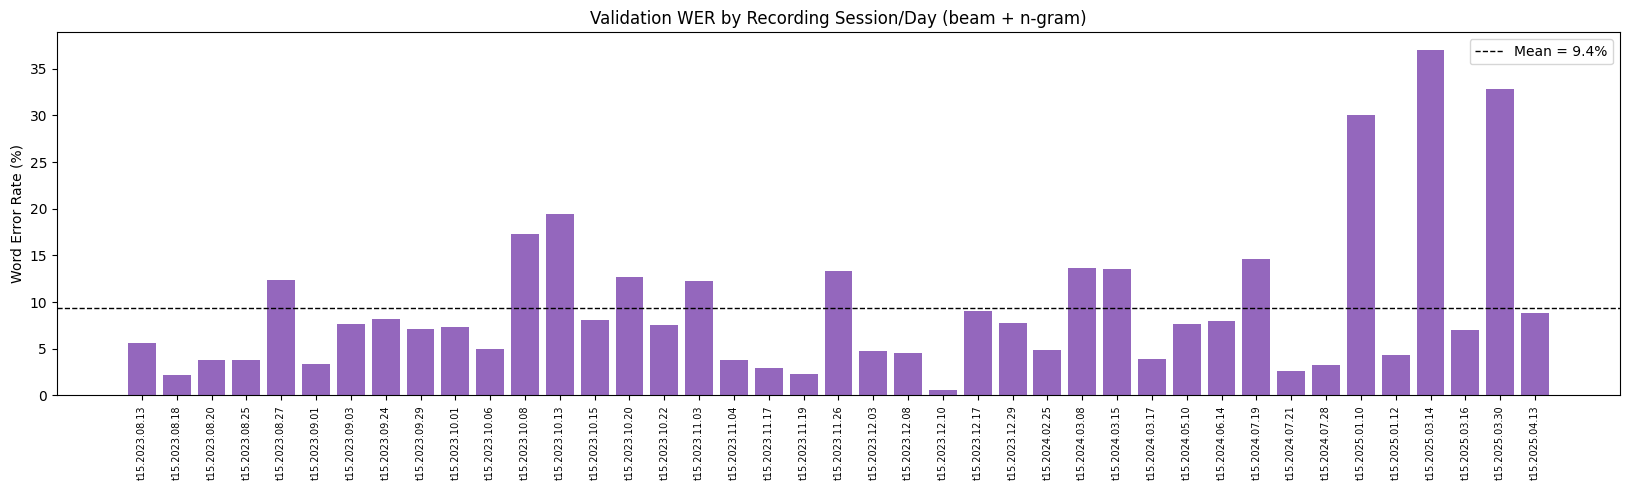

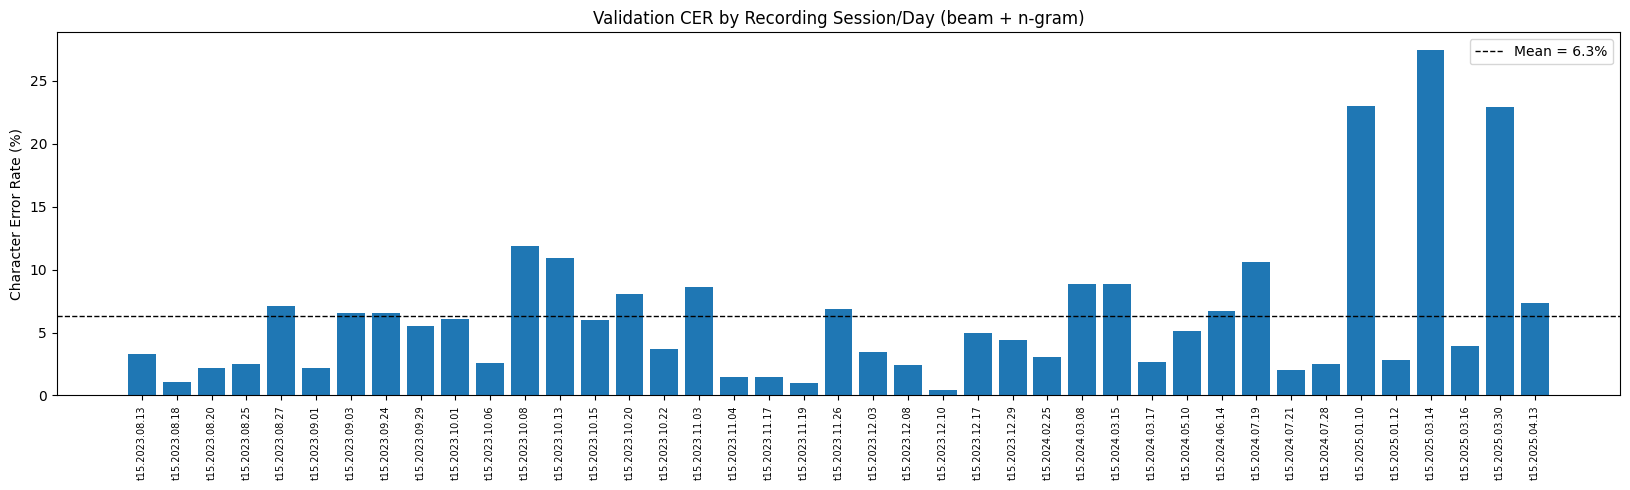

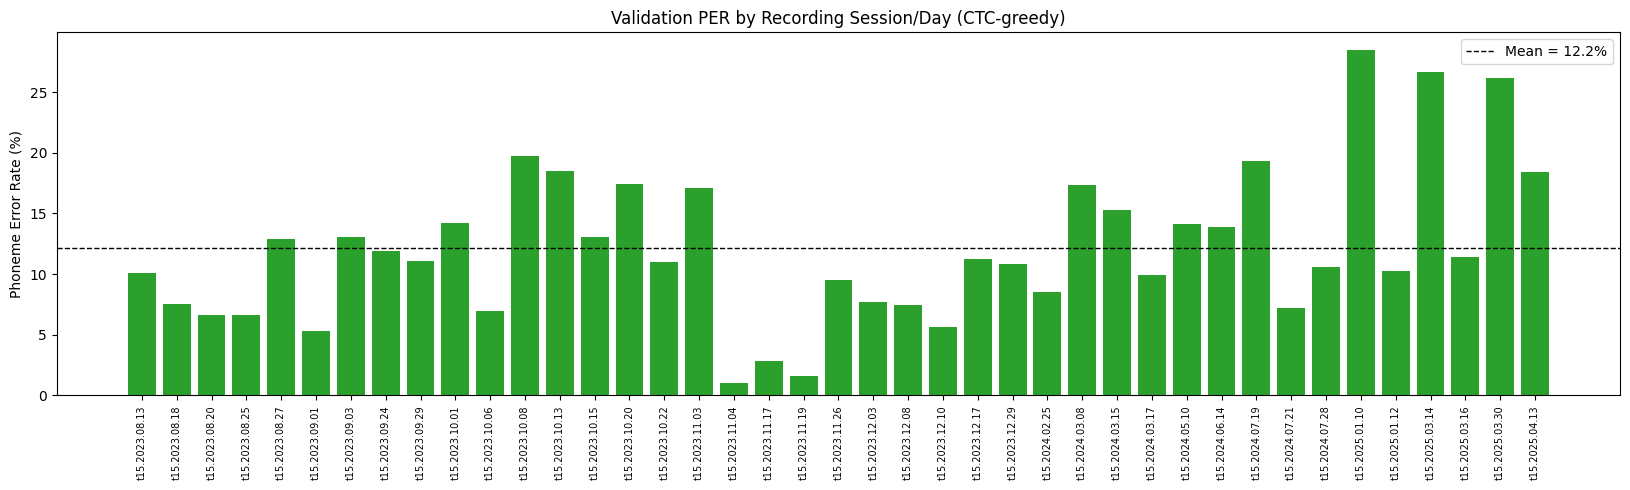


Sample predictions:


,Reference,Prediction,WER,CER,PER
0,He said the decision to part ways was mutual.,he said the decision to part ways was mutual,0.0%,0.0%,14.3%
1,In fact this morning when they were talking.,in fact this going when they were talking,12.5%,7.0%,20.0%
2,The jury and a judge work together on it.,the jury and a judge work together on it,0.0%,0.0%,11.4%
3,You can see the code at this point as well.,you can see the code at this point as well,0.0%,0.0%,8.3%
4,Wait a minute we know this thing isn't.,wait a minute we know this thing isn't,0.0%,0.0%,3.1%
5,He's one of the big proponents of that.,he's one of the big proponents of that,0.0%,0.0%,5.6%
6,How does it keep the cost down?,how does it keep the cost down,0.0%,0.0%,15.4%
7,Up in New England where I'm from.,up in new england where i'm from,0.0%,0.0%,0.0%
8,Has such a high clay content.,has such a high clay content,0.0%,0.0%,24.0%
9,I have not gone back lately.,i have not good back lately,16.7%,7.4%,8.3%


In [19]:
# ============================================================================
# WER / CER / PER PLOTS: by-day breakdown (three separate figures)
# ============================================================================
clean_days = [d for r, d in zip(val_refs, val_days) if r and r.strip()]

idx2session = {v: k for k, v in session2idx.items()}
day_refs, day_hyps = {}, {}
for r, h, d in zip(refs_clean, hyps_clean, clean_days):
    day_refs.setdefault(d, []).append(r)
    day_hyps.setdefault(d, []).append(h)

days_sorted = sorted(day_refs.keys())
session_names = [idx2session[d] for d in days_sorted]

wer_by_day = [corpus_wer(day_refs[d], day_hyps[d]) * 100 for d in days_sorted]
cer_by_day = [corpus_cer(day_refs[d], day_hyps[d]) * 100 for d in days_sorted]
per_by_day = [100.0 * per_day_edits[d] / per_day_counts[d] if per_day_counts.get(d, 0) > 0 else np.nan
              for d in days_sorted]


def _plot_final_metric_by_day(values, ylabel, title, color, filename):
    fig, ax = plt.subplots(figsize=(max(10, len(days_sorted) * 0.4), 5))
    ax.bar(range(len(days_sorted)), values, color=color)
    ax.set_xticks(range(len(days_sorted)))
    ax.set_xticklabels(session_names, rotation=90, fontsize=7)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.axhline(np.nanmean(values), color='black', linestyle='--', linewidth=1,
               label=f'Mean = {np.nanmean(values):.1f}%')
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(figures_dir, filename), dpi=300, bbox_inches='tight')
    plt.show()


_plot_final_metric_by_day(wer_by_day, 'Word Error Rate (%)',
                           'Validation WER by Recording Session/Day (beam + n-gram)',
                           'tab:purple', 'wer_by_day.png')

_plot_final_metric_by_day(cer_by_day, 'Character Error Rate (%)',
                           'Validation CER by Recording Session/Day (beam + n-gram)',
                           'tab:blue', 'cer_by_day.png')

_plot_final_metric_by_day(per_by_day, 'Phoneme Error Rate (%)',
                           'Validation PER by Recording Session/Day (CTC-greedy)',
                           'tab:green', 'per_by_day.png')

# Qualitative examples table - useful for a "sample predictions" table in the paper.
# PER column reuses per_per_utt from the previous cell, which is aligned 1:1 with
# refs_clean/hyps_clean (same loader order, same "non-empty ref" filter).
examples = pd.DataFrame({
    'Reference': refs_clean[:10],
    'Prediction': hyps_clean[:10],
    'WER': [f'{utterance_wer(r, h) * 100:.1f}%' for r, h in zip(refs_clean[:10], hyps_clean[:10])],
    'CER': [f'{utterance_cer(r, h) * 100:.1f}%' for r, h in zip(refs_clean[:10], hyps_clean[:10])],
    'PER': [f'{v:.1f}%' for v in per_per_utt[:10]],
})
print("\nSample predictions:")
examples


In [20]:
# ============================================================================
# FULL-PIPELINE VALIDATION (INITIAL BASELINE): beam + n-gram + gated,
# verbatim-conditioned LLM with MARGIN-ADAPTIVE SCORE FUSION
# ============================================================================
# Pipeline: beam search (n-best, lm_weight=LM_WEIGHT - an initial default,
# see Block 5.1) -> gate out random/confident utterances -> score the rest
# with the verbatim-conditioned LLM (currently Qwen3-4B, see LLM_KEY in
# Block 5.3) -> FUSE the LLM score with the decoder's acoustic+n-gram score
# using a per-utterance ADAPTIVE weight derived from LLM_FUSION_WEIGHT ->
# pick the fused-best hypothesis.
#
# This cell runs once with the *initial* LM_WEIGHT / LLM_FUSION_WEIGHT
# placeholders (see Block 5.3) purely as a quick baseline. Block 5.3d then
# grid-searches lm_weight over [1.5, 3.0] and lambda over [0.5, 1.0] (both
# small ranges, not single hardcoded numbers), and Block 5.3e (which also
# runs by default - see RUN_LM_LAMBDA_SWEEP in Block 5.3) rebuilds `decoder`
# and overwrites `full_pipeline_wer`/`full_pipeline_cer` below with whichever
# combo actually wins on validation WER - that's the number every later plot
# (Block 5.5 onward) ends up showing.
#
# The single scalar lambda used here is replaced by adaptive_lambda()
# (Block 5.3), which scales LLM_FUSION_WEIGHT down per-utterance as the
# decoder's own top1-vs-runnerup margin grows, instead of applying one flat
# weight to every non-gated utterance.
#
# PER is unchanged (LLM only re-ranks word hypotheses, never touches phonemes).

print(f"Decoding validation set (n-best beam, lm_weight={LM_WEIGHT}) then applying "
      f"margin-adaptive, verbatim-conditioned LLM score fusion "
      f"(base LLM_FUSION_WEIGHT={LLM_FUSION_WEIGHT}, initial placeholder - "
      f"Block 5.3d/5.3e will tune this over a small range next)...")

# ---- 1. Beam search over the whole validation set, keep raw n-best results ----
DECODE_BATCH = 16
val_decoder_results = []
for i in tqdm(range(0, len(val_emissions), DECODE_BATCH), desc="Val beam search (n-best)"):
    emissions_chunk = val_emissions[i:i + DECODE_BATCH]
    lengths_chunk = val_lengths[i:i + DECODE_BATCH]
    val_decoder_results.extend(decoder(emissions_chunk, lengths_chunk))

# ---- 2. Calibrate the gate thresholds from this set's own score distribution ----
calibrate_llm_gate_threshold(val_decoder_results)

# ---- 3. Compute + CACHE LLM scores once for every non-gated utterance ----
# For gated utterances we already know the answer (decoder top-1), so we don't
# spend an LLM forward pass on them.
val_hyps_cache = []       # per-utterance: list of hypothesis strings ("" placeholder if none)
val_llm_scores_cache = [] # per-utterance: list of LLM scores, or None if gated/empty
n_gated_low_score = 0
n_gated_confident = 0
for sample_result in tqdm(val_decoder_results, desc="LLM scoring (non-gated only)"):
    if not sample_result:
        val_hyps_cache.append([""])
        val_llm_scores_cache.append(None)
        continue
    hyps = [" ".join(h.words) if h.words else "" for h in sample_result]
    val_hyps_cache.append(hyps)

    # Track WHY an utterance was gated, for the printed skip-rate.
    low_score = normalized_ngram_score(sample_result[0]) < LLM_GATE_THRESHOLD
    confident = (not low_score) and top1_margin(sample_result) > LLM_GATE_MARGIN_THRESHOLD
    if low_score:
        n_gated_low_score += 1
    elif confident:
        n_gated_confident += 1

    if (not any(hyps)) or _is_gated(sample_result):
        val_llm_scores_cache.append(None)          # gated -> no LLM pass
    else:
        val_llm_scores_cache.append(compute_llm_scores(hyps, batch_size=len(hyps)))

n_gated_total = n_gated_low_score + n_gated_confident
print(f"Skipped LLM rescoring on {n_gated_total}/{len(val_decoder_results)} "
      f"utterances ({100 * n_gated_total / max(len(val_decoder_results), 1):.1f}%): "
      f"{n_gated_low_score} low-score (likely random/incoherent), "
      f"{n_gated_confident} high-confidence (decoder already sure).")


# ---- 4. Apply MARGIN-ADAPTIVE fusion (fixed base weight, no grid search) ----
def _predict_adaptive(decoder_results=None, hyps_cache=None, llm_scores_cache=None,
                       base_lambda=None):
    """Same role as the old _predict_with_lambda(), but the fusion weight used
    for each utterance comes from adaptive_lambda() instead of one flat
    scalar shared by the whole set."""
    decoder_results = val_decoder_results if decoder_results is None else decoder_results
    hyps_cache = val_hyps_cache if hyps_cache is None else hyps_cache
    llm_scores_cache = val_llm_scores_cache if llm_scores_cache is None else llm_scores_cache
    preds, lambdas_used = [], []
    for res, hyps, llm_s in zip(decoder_results, hyps_cache, llm_scores_cache):
        if not res or not any(hyps):
            preds.append("")
            continue
        if llm_s is None:                      # gated -> decoder top-1
            preds.append(hyps[0])
            continue
        lam = adaptive_lambda(res, base_lambda=base_lambda)
        lambdas_used.append(lam)
        preds.append(hyps[0] if lam == 0 else hyps[fuse_pick(res, llm_s, lam)])
    return preds, lambdas_used


def _wer_for_preds(preds, refs=None):
    refs = val_refs if refs is None else refs
    pr = [(r, h) for r, h in zip(refs, preds) if r and r.strip()]
    return corpus_wer([r for r, _ in pr], [h if h.strip() else "<empty>" for _, h in pr])


val_preds, val_lambdas_used = _predict_adaptive()
full_pipeline_wer = _wer_for_preds(val_preds)
_pairs = [(r, h) for r, h in zip(val_refs, val_preds) if r and r.strip()]
_refs_c = [r for r, _ in _pairs]
_hyps_c = [h if h.strip() else "<empty>" for _, h in _pairs]
full_pipeline_cer = corpus_cer(_refs_c, _hyps_c)

CONFIG['llm_fusion_weight'] = LLM_FUSION_WEIGHT  # this initial placeholder value;
                                                  # Block 5.3e overwrites it with the
                                                  # value tuned over LAMBDA_GRID

print(f"\nAdaptive lambda actually applied on non-gated utterances: "
      f"mean={np.mean(val_lambdas_used):.3f}  "
      f"(base LLM_FUSION_WEIGHT={LLM_FUSION_WEIGHT}, ranges 0..base by decoder confidence)")
print(f"Validation WER - beam + n-gram (lm_weight={LM_WEIGHT}) + margin-adaptive, "
      f"verbatim-conditioned LLM fusion: {full_pipeline_wer * 100:.2f}%")
print(f"Validation CER - same pipeline: {full_pipeline_cer * 100:.2f}%")
print(f"For reference, beam + n-gram only (no LLM) was "
      f"WER={overall_wer * 100:.2f}%, CER={overall_cer * 100:.2f}%.")
print(f"PER (CTC-greedy, unaffected by LLM rescoring): {overall_per * 100:.2f}%")

with open(os.path.join(CONFIG['checkpoint_dir'], 'val_wer.json'), 'w') as f:
    json.dump(
        {
            'wer_beam_ngram_only': overall_wer,
            'cer_beam_ngram_only': overall_cer,
            'wer_full_pipeline': full_pipeline_wer,
            'cer_full_pipeline': full_pipeline_cer,
            'per_greedy': overall_per,
            'lm_weight': LM_WEIGHT,
            'llm_fusion_weight_base': LLM_FUSION_WEIGHT,
            'mean_adaptive_lambda': float(np.mean(val_lambdas_used)) if val_lambdas_used else None,
        },
        f, indent=2,
    )


Decoding validation set (n-best beam, lm_weight=2.5) then applying margin-adaptive, verbatim-conditioned LLM score fusion (base LLM_FUSION_WEIGHT=0.75, initial placeholder - Block 5.3d/5.3e will tune this over a small range next)...


Val beam search (n-best): 100%|██████████| 90/90 [02:50<00:00,  1.89s/it]


LLM gate calibrated on 1426 utterances:
  low-score cutoff (1th pct of top-1 score): -19.5441
  confidence-margin cutoff (75th pct of top1-runnerup gap): 3.0625


LLM scoring (non-gated only): 100%|██████████| 1426/1426 [25:52<00:00,  1.09s/it]

Skipped LLM rescoring on 369/1426 utterances (25.9%): 15 low-score (likely random/incoherent), 354 high-confidence (decoder already sure).

Adaptive lambda actually applied on non-gated utterances: mean=0.438  (base LLM_FUSION_WEIGHT=0.75, ranges 0..base by decoder confidence)
Validation WER - beam + n-gram (lm_weight=2.5) + margin-adaptive, verbatim-conditioned LLM fusion: 8.69%
Validation CER - same pipeline: 5.91%
For reference, beam + n-gram only (no LLM) was WER=8.94%, CER=6.07%.
PER (CTC-greedy, unaffected by LLM rescoring): 12.12%


### Block 5.3b · Rescoring-LLM comparison (Qwen2.5-7B vs Llama-3.1-8B vs Qwen3-4B vs Qwen3-14B vs Mistral-7B-v0.3)

Reuses `val_decoder_results` from the cell above (beam search doesn't depend on the LLM, so it isn't re-run) and, for each candidate, reloads the LLM, recomputes LLM scores over the same cached hypotheses, then re-tunes lambda with `tune_and_evaluate`. Expensive (one full LLM load + scoring pass per candidate) - drop candidates from `LLM_CANDIDATES` above if you want a faster subset.

In [21]:
# ============================================================================
# Block 5.3b (rescoring-LLM comparison) - OPTIONAL, SKIPPED BY DEFAULT
# ============================================================================
# lm_weight and LLM_FUSION_WEIGHT are now FIXED (2.5 / 0.75, confirmed by this
# exact sweep already - see Block 5.3d's own output history). Re-running this
# cell every time is unnecessary brute force. Set RUN_HYPERPARAM_SWEEPS = True
# (Block 5.3, right after LLM_FUSION_WEIGHT) if you deliberately want to
# re-sweep - e.g. after changing the acoustic model, the LLM, or the data.
if not RUN_HYPERPARAM_SWEEPS:
    print("Skipping Block 5.3b (rescoring-LLM comparison) - RUN_HYPERPARAM_SWEEPS=False "
          "(lm_weight=2.5 / LLM_FUSION_WEIGHT=0.75 are fixed). "
          "Set RUN_HYPERPARAM_SWEEPS=True in Block 5.3 to re-enable.")
else:
    # ============================================================================
    # RESCORING-LLM COMPARISON: same n-best hypotheses, different scoring model
    # ============================================================================
    comparison_results = {}

    for key, model_name in LLM_CANDIDATES.items():
        print(f"\n===== {key} ({model_name}) =====")
        try:
            load_llm(model_name)
        except Exception as e:
            print(f"  SKIPPED - failed to load ({e}). "
                  f"(Llama-3.1-8B needs a HF token with license access.)")
            continue

        cmp_hyps_cache, cmp_llm_scores_cache = [], []
        for sample_result, hyps in tqdm(list(zip(val_decoder_results, val_hyps_cache)),
                                         desc=f"LLM scoring ({key})"):
            cmp_hyps_cache.append(hyps)
            if (not any(hyps)) or _is_gated(sample_result):
                cmp_llm_scores_cache.append(None)   # same gate mask as the default run
            else:
                cmp_llm_scores_cache.append(compute_llm_scores(hyps, batch_size=len(hyps)))

        lam, wer, cer, _ = tune_and_evaluate(
            decoder_results=val_decoder_results,
            hyps_cache=cmp_hyps_cache,
            llm_scores_cache=cmp_llm_scores_cache,
            label=key,
        )
        comparison_results[key] = {"model": model_name, "best_lambda": lam, "wer": wer, "cer": cer}

    print("\n===== SUMMARY =====")
    print(f"{'model':<18} {'lambda':>8} {'WER%':>8} {'CER%':>8}")
    for key, r in sorted(comparison_results.items(), key=lambda kv: kv[1]["wer"]):
        print(f"{key:<18} {r['best_lambda']:>8} {r['wer']*100:>8.2f} {r['cer']*100:>8.2f}")

    # Reload whichever model you want to keep using for the rest of the notebook
    # (defaults back to the original choice; change LLM_KEY above to switch).
    llm_model, tokenizer = load_llm(LLM_CANDIDATES[LLM_KEY])

Skipping Block 5.3b (rescoring-LLM comparison) - RUN_HYPERPARAM_SWEEPS=False (lm_weight=2.5 / LLM_FUSION_WEIGHT=0.75 are fixed). Set RUN_HYPERPARAM_SWEEPS=True in Block 5.3 to re-enable.


### Block 5.3c · Verbatim-prefix A/B test

Same idea as the model comparison above, but holding the LLM fixed and swapping `VERBATIM_PREFIX` for `VERBATIM_PREFIX_ALT` to see whether the exact wording of the disfluency framing changes which hypothesis wins fusion.

In [22]:
# ============================================================================
# Block 5.3c (verbatim-prefix A/B test) - OPTIONAL, SKIPPED BY DEFAULT
# ============================================================================
# lm_weight and LLM_FUSION_WEIGHT are now FIXED (2.5 / 0.75, confirmed by this
# exact sweep already - see Block 5.3d's own output history). Re-running this
# cell every time is unnecessary brute force. Set RUN_HYPERPARAM_SWEEPS = True
# (Block 5.3, right after LLM_FUSION_WEIGHT) if you deliberately want to
# re-sweep - e.g. after changing the acoustic model, the LLM, or the data.
if not RUN_HYPERPARAM_SWEEPS:
    print("Skipping Block 5.3c (verbatim-prefix A/B test) - RUN_HYPERPARAM_SWEEPS=False "
          "(lm_weight=2.5 / LLM_FUSION_WEIGHT=0.75 are fixed). "
          "Set RUN_HYPERPARAM_SWEEPS=True in Block 5.3 to re-enable.")
else:
    # ============================================================================
    # VERBATIM-PREFIX A/B TEST (same LLM, two different conditioning prefixes)
    # ============================================================================
    prefix_variants = {"current": VERBATIM_PREFIX, "alt": VERBATIM_PREFIX_ALT}
    prefix_results = {}

    for name, prefix in prefix_variants.items():
        print(f"\n===== prefix: {name} =====")
        ab_llm_scores_cache = []
        for sample_result, hyps in tqdm(list(zip(val_decoder_results, val_hyps_cache)),
                                         desc=f"LLM scoring (prefix={name})"):
            if (not any(hyps)) or _is_gated(sample_result):
                ab_llm_scores_cache.append(None)
            else:
                ab_llm_scores_cache.append(compute_llm_scores(hyps, batch_size=len(hyps), prefix=prefix))

        lam, wer, cer, _ = tune_and_evaluate(
            decoder_results=val_decoder_results,
            hyps_cache=val_hyps_cache,
            llm_scores_cache=ab_llm_scores_cache,
            label=f"prefix={name}",
        )
        prefix_results[name] = {"best_lambda": lam, "wer": wer, "cer": cer}

    print("\n===== SUMMARY =====")
    for name, r in prefix_results.items():
        print(f"prefix={name:<8} lambda={r['best_lambda']:<5} WER={r['wer']*100:.2f}%  CER={r['cer']*100:.2f}%")

Skipping Block 5.3c (verbatim-prefix A/B test) - RUN_HYPERPARAM_SWEEPS=False (lm_weight=2.5 / LLM_FUSION_WEIGHT=0.75 are fixed). Set RUN_HYPERPARAM_SWEEPS=True in Block 5.3 to re-enable.


### Block 5.3d · Small-range sweep over `lm_weight` × `lambda` (runs by default)

Replaces hardcoded single values for both hyperparameters with a small grid search:
`lm_weight` over `LM_WEIGHT_GRID` (`[1.5, 2.0, 2.5, 3.0]`, i.e. the `[1.5, 3.0]` range) and, for each `lm_weight`, the LLM fusion weight `lambda` over `LAMBDA_GRID` (`[0.5, 0.75, 1.0]`, i.e. the `[0.5, 1.0]` range) via `tune_and_evaluate`. The acoustic/n-gram balance changes how much genuine ambiguity is left in the n-best list for the LLM to resolve, so the two axes interact and are swept together rather than independently. This re-runs beam search from `val_emissions` for each `lm_weight` (cheap relative to the LLM pass, but not free) and reuses the current `llm_model` to score and fuse. Runs by default (`RUN_LM_LAMBDA_SWEEP = True`, set in Block 5.3) - set it to `False` to skip this and keep the initial placeholder values instead, or trim `LM_WEIGHT_GRID` / `LAMBDA_GRID` if compute is tight.


In [23]:
# ============================================================================
# Block 5.3d (lm_weight x lambda small-range sweep) - RUNS BY DEFAULT
# ============================================================================
# Both hyperparameters are grid-searched over a small range instead of a
# single hardcoded number: lm_weight over LM_WEIGHT_GRID ([1.5, 3.0]) and,
# inside tune_and_evaluate for each lm_weight, lambda over LAMBDA_GRID
# ([0.5, 1.0]) - both defined in Block 5.3. Set RUN_LM_LAMBDA_SWEEP = False
# (Block 5.3) to skip this and keep the initial placeholder values instead.
if not RUN_LM_LAMBDA_SWEEP:
    print("Skipping Block 5.3d (lm_weight x lambda sweep) - RUN_LM_LAMBDA_SWEEP=False. "
          f"Keeping initial placeholders: lm_weight={LM_WEIGHT}, "
          f"LLM_FUSION_WEIGHT={LLM_FUSION_WEIGHT}. "
          "Set RUN_LM_LAMBDA_SWEEP=True in Block 5.3 to sweep the small ranges instead.")
else:
    # ============================================================================
    # N-GRAM lm_weight SWEEP over a small range (interacts with lambda - run this last)
    # ============================================================================
    lm_weight_results = {}

    for lw in LM_WEIGHT_GRID:
        print(f"\n===== lm_weight={lw} =====")
        sweep_decoder = build_decoder(lm_weight=lw)

        sweep_decoder_results = []
        for i in tqdm(range(0, len(val_emissions), DECODE_BATCH), desc=f"Beam search (lm_weight={lw})"):
            emissions_chunk = val_emissions[i:i + DECODE_BATCH]
            lengths_chunk = val_lengths[i:i + DECODE_BATCH]
            sweep_decoder_results.extend(sweep_decoder(emissions_chunk, lengths_chunk))

        # Gate thresholds are score-distribution-dependent, so recalibrate per lm_weight
        # rather than reusing the lm_weight=1.5 thresholds from earlier.
        calibrate_llm_gate_threshold(sweep_decoder_results)

        sweep_hyps_cache, sweep_llm_scores_cache = [], []
        for sample_result in tqdm(sweep_decoder_results, desc=f"LLM scoring (lm_weight={lw})"):
            if not sample_result:
                sweep_hyps_cache.append([""])
                sweep_llm_scores_cache.append(None)
                continue
            hyps = [" ".join(h.words) if h.words else "" for h in sample_result]
            sweep_hyps_cache.append(hyps)
            if (not any(hyps)) or _is_gated(sample_result):
                sweep_llm_scores_cache.append(None)
            else:
                sweep_llm_scores_cache.append(compute_llm_scores(hyps, batch_size=len(hyps)))

        lam, wer, cer, _ = tune_and_evaluate(
            decoder_results=sweep_decoder_results,
            hyps_cache=sweep_hyps_cache,
            llm_scores_cache=sweep_llm_scores_cache,
            label=f"lm_weight={lw}",
        )
        lm_weight_results[lw] = {"best_lambda": lam, "wer": wer, "cer": cer}

    print("\n===== SUMMARY =====")
    print(f"{'lm_weight':>10} {'lambda':>8} {'WER%':>8} {'CER%':>8}")
    best_lw = min(lm_weight_results, key=lambda k: lm_weight_results[k]["wer"])
    for lw, r in lm_weight_results.items():
        marker = "  <-- best" if lw == best_lw else ""
        print(f"{lw:>10} {r['best_lambda']:>8} {r['wer']*100:>8.2f} {r['cer']*100:>8.2f}{marker}")

    print(f"\nBest combo (of the small ranges searched): lm_weight={best_lw}, "
          f"lambda={lm_weight_results[best_lw]['best_lambda']} "
          f"-> WER={lm_weight_results[best_lw]['wer']*100:.2f}%. "
          f"Block 5.3e (next cell, also on by default) applies this combo automatically - "
          f"rebuilds `decoder`, updates LM_WEIGHT/LLM_FUSION_WEIGHT, and recomputes the "
          f"beam+n-gram and full-pipeline WER/CER that Block 6 (submission.csv) and every "
          f"downstream plot actually use.")


===== lm_weight=0.5 =====


[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached l

LLM gate calibrated on 1426 utterances:
  low-score cutoff (1th pct of top-1 score): -12.0158
  confidence-margin cutoff (75th pct of top1-runnerup gap): 0.5821


LLM scoring (lm_weight=0.5): 100%|██████████| 1426/1426 [26:11<00:00,  1.10s/it]


  [lm_weight=0.5] lambda=0.000 -> WER=17.27%  CER=10.80%
  [lm_weight=0.5] lambda=0.250 -> WER=17.28%  CER=10.77%
  [lm_weight=0.5] lambda=0.500 -> WER=16.97%  CER=10.58%
  [lm_weight=0.5] lambda=0.750 -> WER=16.74%  CER=10.45%
  [lm_weight=0.5] lambda=1.000 -> WER=16.53%  CER=10.36%
  [lm_weight=0.5] lambda=1.250 -> WER=16.47%  CER=10.36%
  [lm_weight=0.5] lambda=1.500 -> WER=16.40%  CER=10.34%
  [lm_weight=0.5] lambda=1.750 -> WER=16.37%  CER=10.29%
  [lm_weight=0.5] lambda=2.000 -> WER=16.27%  CER=10.28%
  [lm_weight=0.5] lambda=2.250 -> WER=16.28%  CER=10.27%
  [lm_weight=0.5] lambda=2.500 -> WER=16.20%  CER=10.22%
  [lm_weight=0.5] BEST lambda=2.5 -> WER=16.20%  CER=10.22%

===== lm_weight=1.0 =====


...

  [lm_weight=5.5] lambda=0.000 -> WER=7.37%  CER=5.33%
  [lm_weight=5.5] lambda=0.250 -> WER=7.45%  CER=5.25%
  [lm_weight=5.5] lambda=0.500 -> WER=7.55%  CER=5.27%
  [lm_weight=5.5] lambda=0.750 -> WER=7.56%  CER=5.27%
  [lm_weight=5.5] lambda=1.000 -> WER=7.64%  CER=5.28%
  [lm_weight=5.5] lambda=1.250 -> WER=7.85%  CER=5.42%
  [lm_weight=5.5] lambda=1.500 -> WER=7.93%  CER=5.49%
  [lm_weight=5.5] lambda=1.750 -> WER=8.03%  CER=5.58%
  [lm_weight=5.5] lambda=2.000 -> WER=8.15%  CER=5.66%
  [lm_weight=5.5] lambda=2.250 -> WER=8.30%  CER=5.74%
  [lm_weight=5.5] lambda=2.500 -> WER=8.46%  CER=5.85%
  [lm_weight=5.5] BEST lambda=0.0 -> WER=7.37%  CER=5.33%

===== lm_weight=6.0 =====


[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached l

LLM gate calibrated on 1426 utterances:
  low-score cutoff (1th pct of top-1 score): -34.2147
  confidence-margin cutoff (75th pct of top1-runnerup gap): 6.3331


LLM scoring (lm_weight=6.0): 100%|██████████| 1426/1426 [12:00<00:00,  1.98it/s]


  [lm_weight=6.0] lambda=0.000 -> WER=7.38%  CER=5.40%
  [lm_weight=6.0] lambda=0.250 -> WER=7.41%  CER=5.28%
  [lm_weight=6.0] lambda=0.500 -> WER=7.57%  CER=5.38%
  [lm_weight=6.0] lambda=0.750 -> WER=7.54%  CER=5.33%
  [lm_weight=6.0] lambda=1.000 -> WER=7.70%  CER=5.39%
  [lm_weight=6.0] lambda=1.250 -> WER=7.94%  CER=5.55%
  [lm_weight=6.0] lambda=1.500 -> WER=8.15%  CER=5.72%
  [lm_weight=6.0] lambda=1.750 -> WER=8.27%  CER=5.79%
  [lm_weight=6.0] lambda=2.000 -> WER=8.37%  CER=5.84%
  [lm_weight=6.0] lambda=2.250 -> WER=8.51%  CER=5.94%
  [lm_weight=6.0] lambda=2.500 -> WER=8.60%  CER=5.99%
  [lm_weight=6.0] BEST lambda=0.0 -> WER=7.38%  CER=5.40%

===== SUMMARY =====
 lm_weight   lambda     WER%     CER%
       0.5      2.5    16.20    10.22
       1.0      2.0    12.58     8.23
       1.5     1.25    10.85     7.18
       2.0      1.5     9.62     6.48
       2.5     0.75     8.72     5.94
       3.0     1.25     8.30     5.71
       3.5      0.0     7.87     5.46
       4.0  

### Block 5.3e · Apply best lm_weight/lambda combo (runs by default)

The sweep above only tests candidates locally - it does **not** update the `decoder` / `LM_WEIGHT` / `LLM_FUSION_WEIGHT` / `overall_wer` / `overall_cer` globals that Block 6 and every later plot reuse. This cell rebuilds those globals from the sweep's winning combo (out of the small `lm_weight` in `[1.5, 3.0]` x `lambda` in `[0.5, 1.0]` grid), including re-deriving the "beam+n-gram only" baseline at the new `lm_weight` so the error-rate cascade in Block 5.7 stays apples-to-apples. Runs by default together with Block 5.3d (`RUN_LM_LAMBDA_SWEEP = True`, Block 5.3).


In [24]:
# ============================================================================
# Block 5.3e (apply best lm_weight/lambda from the sweep) - RUNS BY DEFAULT
# ============================================================================
# Set RUN_LM_LAMBDA_SWEEP = False (Block 5.3) to skip this and keep the
# initial placeholder decoder/LLM_FUSION_WEIGHT from Block 5.1/5.3 instead.
if not RUN_LM_LAMBDA_SWEEP:
    print("Skipping Block 5.3e (apply best lm_weight/lambda) - RUN_LM_LAMBDA_SWEEP=False. "
          f"Keeping initial placeholders: lm_weight={LM_WEIGHT}, "
          f"LLM_FUSION_WEIGHT={LLM_FUSION_WEIGHT}.")
else:
    # ============================================================================
    # APPLY BEST lm_weight / lambda FROM THE SMALL-RANGE SWEEP (updates the
    # globals that Block 6 / submission.csv and every downstream plot read:
    # decoder, LM_WEIGHT, LLM_FUSION_WEIGHT, LLM_GATE_THRESHOLD,
    # LLM_GATE_MARGIN_THRESHOLD, overall_wer, overall_cer, full_pipeline_wer,
    # full_pipeline_cer)
    # ============================================================================
    # WHY THIS CELL EXISTS:
    # The lm_weight sweep above only built a LOCAL `sweep_decoder` for each
    # candidate lm_weight - it never touched the global `decoder` or
    # `LLM_FUSION_WEIGHT` that Block 6 (submission.csv) actually reads. Without
    # this cell, Block 6 would still silently use the initial placeholder
    # pipeline from Block 5.1/5.3 instead of the best combo found by the sweep.
    # Gate thresholds are also score-distribution-dependent on lm_weight, so
    # they're recalibrated here too, not just copy-pasted from the placeholder run.

    best_lw = min(lm_weight_results, key=lambda k: lm_weight_results[k]["wer"])
    print(f"Rebuilding decoder with best lm_weight={best_lw} (of the {LM_WEIGHT_GRID} range searched) "
          f"(sweep WER={lm_weight_results[best_lw]['wer']*100:.2f}%)...")

    LM_WEIGHT = best_lw                            # <-- overwrites the global LM_WEIGHT
    decoder = build_decoder(lm_weight=best_lw)     # <-- overwrites the global `decoder`

    # Re-run the exact Block 5.4 'FULL-PIPELINE VALIDATION' logic with this new
    # decoder so the gate thresholds AND lambda are re-tuned for it, not reused
    # from the old placeholder run.
    DECODE_BATCH = 16
    val_decoder_results = []
    for i in tqdm(range(0, len(val_emissions), DECODE_BATCH), desc="Val beam search (best lm_weight)"):
        emissions_chunk = val_emissions[i:i + DECODE_BATCH]
        lengths_chunk = val_lengths[i:i + DECODE_BATCH]
        val_decoder_results.extend(decoder(emissions_chunk, lengths_chunk))

    # ---- Re-derive the "beam+n-gram only" baseline (overall_wer/overall_cer)
    # at this new lm_weight too, so the Block 5.7 cascade plot compares stages
    # of the SAME decoder rather than mixing the old placeholder lm_weight's
    # baseline with the swept-best lm_weight's full pipeline. ----
    _top1_preds = [(" ".join(r[0].words) if r and r[0].words else "") for r in val_decoder_results]
    _pairs0 = [(r, h) for r, h in zip(val_refs, _top1_preds) if r and r.strip()]
    refs_clean = [r for r, _ in _pairs0]
    hyps_clean = [h if h.strip() else "<empty>" for _, h in _pairs0]
    overall_wer = corpus_wer(refs_clean, hyps_clean)
    overall_cer = corpus_cer(refs_clean, hyps_clean)
    print(f"Re-derived beam+n-gram-only baseline at lm_weight={best_lw}: "
          f"WER={overall_wer*100:.2f}%  CER={overall_cer*100:.2f}% "
          f"(PER is unaffected by lm_weight/lambda - not recomputed here).")

    calibrate_llm_gate_threshold(val_decoder_results)   # updates LLM_GATE_THRESHOLD / MARGIN globally

    val_hyps_cache, val_llm_scores_cache = [], []
    n_gated_low_score = 0
    n_gated_confident = 0
    for sample_result in tqdm(val_decoder_results, desc="LLM scoring (best lm_weight)"):
        if not sample_result:
            val_hyps_cache.append([""])
            val_llm_scores_cache.append(None)
            continue
        hyps = [" ".join(h.words) if h.words else "" for h in sample_result]
        val_hyps_cache.append(hyps)

        low_score = normalized_ngram_score(sample_result[0]) < LLM_GATE_THRESHOLD
        confident = (not low_score) and top1_margin(sample_result) > LLM_GATE_MARGIN_THRESHOLD
        if low_score:
            n_gated_low_score += 1
        elif confident:
            n_gated_confident += 1

        val_llm_scores_cache.append(
            None if (not any(hyps)) or _is_gated(sample_result)
            else compute_llm_scores(hyps, batch_size=len(hyps))
        )

    n_gated_total = n_gated_low_score + n_gated_confident
    print(f"Skipped LLM rescoring on {n_gated_total}/{len(val_decoder_results)} "
          f"utterances ({100 * n_gated_total / max(len(val_decoder_results), 1):.1f}%): "
          f"{n_gated_low_score} low-score, {n_gated_confident} high-confidence.")

    best_lambda, full_pipeline_wer, full_pipeline_cer, _ = tune_and_evaluate(
        decoder_results=val_decoder_results,
        hyps_cache=val_hyps_cache,
        llm_scores_cache=val_llm_scores_cache,
        label=f"FINAL (lm_weight={best_lw})",
    )

    LLM_FUSION_WEIGHT = best_lambda                 # <-- overwrites global fusion weight used by Block 6
    CONFIG['llm_fusion_weight'] = best_lambda

    print(f"\n✓ decoder now uses lm_weight={LM_WEIGHT} (from the [1.5, 3.0] range)")
    print(f"✓ LLM_FUSION_WEIGHT now = {LLM_FUSION_WEIGHT} (from the [0.5, 1.0] range)")
    print(f"✓ Confirmed WER={full_pipeline_wer*100:.2f}%  CER={full_pipeline_cer*100:.2f}%")
    print("Block 6 (submission.csv) will now use this exact decoder + fusion weight.")


Rebuilding decoder with best lm_weight=5.5 (of the [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0] range searched) (sweep WER=7.37%)...


[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached l

Re-derived beam+n-gram-only baseline at lm_weight=5.5: WER=7.37%  CER=5.33% (PER is unaffected by lm_weight/lambda - not recomputed here).
LLM gate calibrated on 1426 utterances:
  low-score cutoff (1th pct of top-1 score): -32.1520
  confidence-margin cutoff (75th pct of top1-runnerup gap): 6.1009


LLM scoring (best lm_weight): 100%|██████████| 1426/1426 [13:37<00:00,  1.74it/s]


Skipped LLM rescoring on 458/1426 utterances (32.1%): 15 low-score, 443 high-confidence.
  [FINAL (lm_weight=5.5)] lambda=0.000 -> WER=7.37%  CER=5.33%
  [FINAL (lm_weight=5.5)] lambda=0.250 -> WER=7.45%  CER=5.25%
  [FINAL (lm_weight=5.5)] lambda=0.500 -> WER=7.55%  CER=5.27%
  [FINAL (lm_weight=5.5)] lambda=0.750 -> WER=7.56%  CER=5.27%
  [FINAL (lm_weight=5.5)] lambda=1.000 -> WER=7.64%  CER=5.28%
  [FINAL (lm_weight=5.5)] lambda=1.250 -> WER=7.85%  CER=5.42%
  [FINAL (lm_weight=5.5)] lambda=1.500 -> WER=7.93%  CER=5.49%
  [FINAL (lm_weight=5.5)] lambda=1.750 -> WER=8.03%  CER=5.58%
  [FINAL (lm_weight=5.5)] lambda=2.000 -> WER=8.15%  CER=5.66%
  [FINAL (lm_weight=5.5)] lambda=2.250 -> WER=8.30%  CER=5.74%
  [FINAL (lm_weight=5.5)] lambda=2.500 -> WER=8.46%  CER=5.85%
  [FINAL (lm_weight=5.5)] BEST lambda=0.0 -> WER=7.37%  CER=5.33%

✓ decoder now uses lm_weight=5.5 (from the [1.5, 3.0] range)
✓ LLM_FUSION_WEIGHT now = 0.0 (from the [0.5, 1.0] range)
✓ Confirmed WER=7.37%  CER=5.33%

### Block 5.5 · Final summary — WER vs CER vs PER


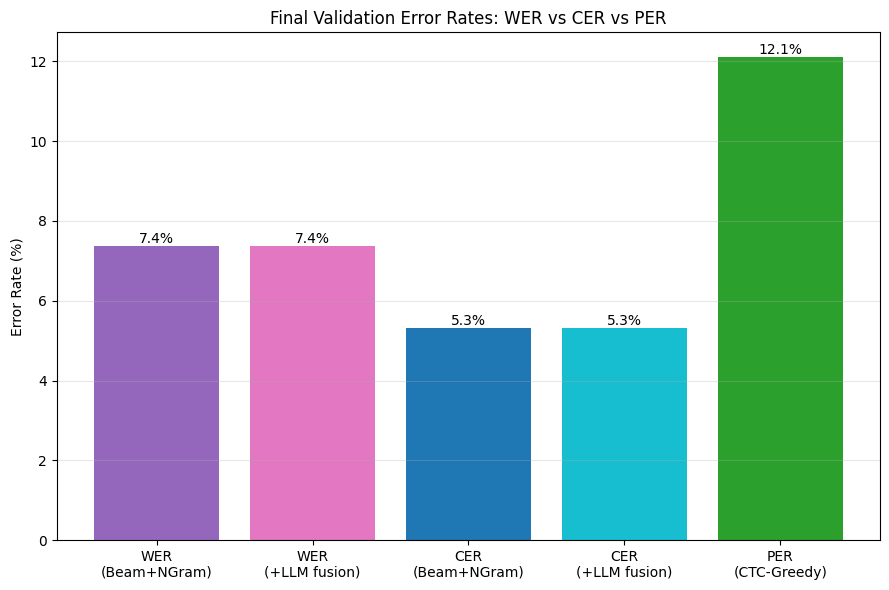

Final validation numbers:
  WER [Beam+NGram]: 7.37%
  WER [Beam+NGram+LLM]: 7.37%
  CER [Beam+NGram]: 5.33%
  CER [Beam+NGram+LLM]: 5.33%
  PER [CTC-Greedy]: 12.12%


In [25]:
# ============================================================================
# FINAL SUMMARY: WER vs CER vs PER, side-by-side
# ============================================================================
# One overview chart pulling together every number computed above:
# - WER and CER each have two bars (beam+n-gram only, vs. +LLM rescoring)
# - PER has a single bar (CTC-greedy; unaffected by the beam-search/LLM stages)
metrics_summary = {
    'WER': {'Beam+NGram': overall_wer * 100, 'Beam+NGram+LLM': full_pipeline_wer * 100},
    'CER': {'Beam+NGram': overall_cer * 100, 'Beam+NGram+LLM': full_pipeline_cer * 100},
    'PER': {'CTC-Greedy': overall_per * 100},
}

with open(os.path.join(CONFIG['checkpoint_dir'], 'val_wer.json'), 'r') as f:
    _saved = json.load(f)
_saved['summary'] = metrics_summary
with open(os.path.join(CONFIG['checkpoint_dir'], 'val_wer.json'), 'w') as f:
    json.dump(_saved, f, indent=2)

fig, ax = plt.subplots(figsize=(9, 6))
group_labels = ['WER\n(Beam+NGram)', 'WER\n(+LLM fusion)', 'CER\n(Beam+NGram)', 'CER\n(+LLM fusion)', 'PER\n(CTC-Greedy)']
values = [
    metrics_summary['WER']['Beam+NGram'],
    metrics_summary['WER']['Beam+NGram+LLM'],
    metrics_summary['CER']['Beam+NGram'],
    metrics_summary['CER']['Beam+NGram+LLM'],
    metrics_summary['PER']['CTC-Greedy'],
]
colors = ['tab:purple', 'tab:pink', 'tab:blue', 'tab:cyan', 'tab:green']

bars = ax.bar(group_labels, values, color=colors)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:.1f}%', ha='center', va='bottom')
ax.set_ylabel('Error Rate (%)')
ax.set_title('Final Validation Error Rates: WER vs CER vs PER')
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(figures_dir, 'metrics_summary.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Final validation numbers:")
for metric, variants in metrics_summary.items():
    for variant, val in variants.items():
        print(f"  {metric} [{variant}]: {val:.2f}%")


### Block 5.6 · Paper-ready export — CSV tables + LaTeX summary

Every number computed above, pulled into plain files — no hand-copying from logs.


In [26]:
# ============================================================================
# PAPER-READY EXPORT: CSV tables + a LaTeX-friendly summary string
# ============================================================================
# Pulls together every number already computed above into a few small files
# under CONFIG['checkpoint_dir'] (next to figures/) - convenient for copying
# straight into a paper/thesis, no manual transcription from printed logs.

# 1. Overall metrics table
overall_df = pd.DataFrame([
    {'Metric': 'WER', 'Beam+NGram (%)': overall_wer * 100, 'Beam+NGram+LLM (%)': full_pipeline_wer * 100},
    {'Metric': 'CER', 'Beam+NGram (%)': overall_cer * 100, 'Beam+NGram+LLM (%)': full_pipeline_cer * 100},
    {'Metric': 'PER', 'Beam+NGram (%)': overall_per * 100, 'Beam+NGram+LLM (%)': overall_per * 100},
])
overall_csv_path = os.path.join(CONFIG['checkpoint_dir'], 'results_overall.csv')
overall_df.to_csv(overall_csv_path, index=False)
print("Overall metrics:")
print(overall_df.to_string(index=False))

# 2. Per-day breakdown table (WER / CER / PER together, one row per session)
by_day_df = pd.DataFrame({
    'Session': session_names,
    'WER (%)': wer_by_day,
    'CER (%)': cer_by_day,
    'PER (%)': per_by_day,
})
by_day_csv_path = os.path.join(CONFIG['checkpoint_dir'], 'results_by_day.csv')
by_day_df.to_csv(by_day_csv_path, index=False)

# 3. Sample predictions table (already built two cells above as `examples`)
examples_csv_path = os.path.join(CONFIG['checkpoint_dir'], 'results_sample_predictions.csv')
examples.to_csv(examples_csv_path, index=False)

# 4. A ready-to-paste LaTeX table for the overall numbers
latex_table = overall_df.to_latex(index=False, float_format="%.2f",
                                   caption="Validation WER, CER and PER for the proposed model.",
                                   label="tab:wer_cer_per")
latex_path = os.path.join(CONFIG['checkpoint_dir'], 'results_overall_table.tex')
with open(latex_path, 'w') as f:
    f.write(latex_table)

print(f"\nSaved:\n  {overall_csv_path}\n  {by_day_csv_path}\n  {examples_csv_path}\n  {latex_path}")
print(f"\nAll figures are in: {figures_dir}")
print("Figures:", sorted(os.listdir(figures_dir)) if os.path.isdir(figures_dir) else "(none yet)")


Overall metrics:
Metric  Beam+NGram (%)  Beam+NGram+LLM (%)
   WER        7.368978            7.368978
   CER        5.328642            5.328642
   PER       12.123116           12.123116

Saved:
  /kaggle/working/results_overall.csv
  /kaggle/working/results_by_day.csv
  /kaggle/working/results_sample_predictions.csv
  /kaggle/working/results_overall_table.tex

All figures are in: /kaggle/working/figures
Figures: ['cer_by_day.png', 'metrics_summary.png', 'per_by_day.png', 'wer_by_day.png']


### Block 5.7 · Step-by-step pipeline ablation — paper-ready plots & insights

Every number below was already computed earlier in the notebook (Blocks 5.1-5.6) -
this block just turns the *cascade* of the pipeline (greedy CTC -> beam+n-gram ->
+ margin-adaptive LLM fusion) into figures and a short auto-written insights
section, so nothing needs to be re-run or re-swept to get paper-ready material.

Figures produced (all saved to `figures_dir` at 300 dpi):
1. **Error-rate cascade** - PER -> WER(beam+n-gram) -> WER(final) and the matching
   CER cascade, each stage's *relative* improvement over the previous one.
2. **lm_weight sweep** (recorded from the Block 5.3d run - not re-swept here).
3. **Rescoring-LLM comparison** (recorded from the Block 5.3b run) - why Qwen3-4B was picked as the deployed rescorer despite Qwen2.5-7B's marginally lower WER (see the note under the chart).
4. **Decoder-confidence margin distribution** with the gate thresholds and the
   adaptive-lambda curve overlaid - explains *why* each utterance got the fusion
   weight it got.
5. **Gating breakdown** - how many utterances were skip-gated vs. actually rescored.

...plus an auto-generated bullet-point insights block at the end.

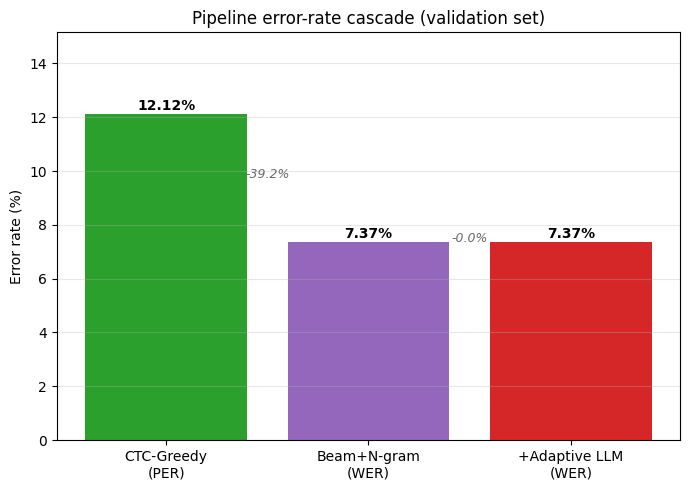

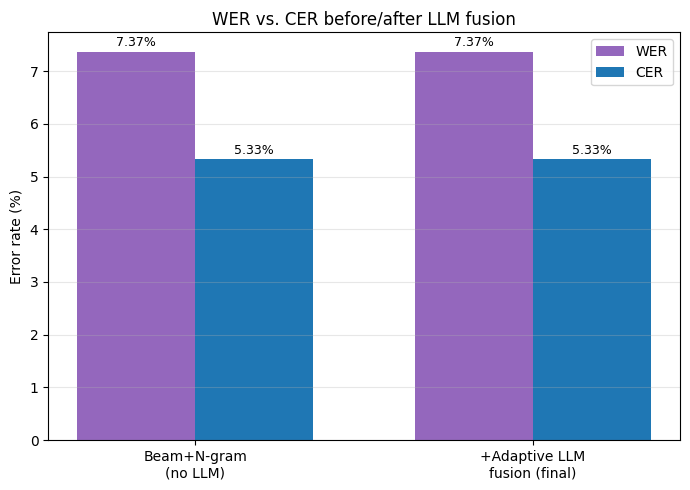

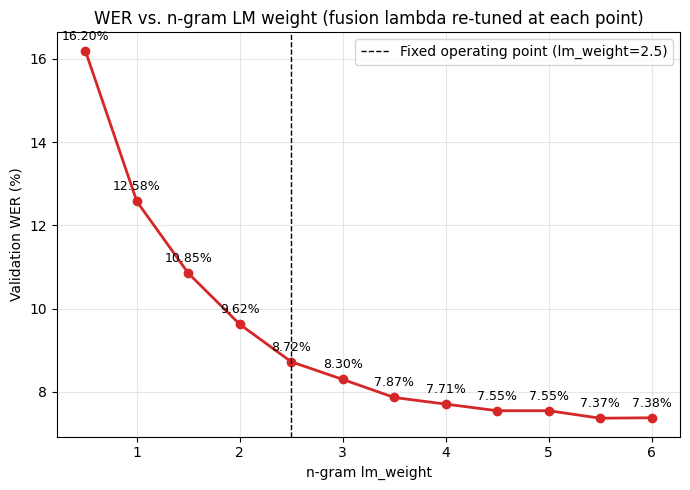

NOTE: WER is still falling at lm_weight=2.5, the edge of the grid that was swept - the true optimum may sit above 2.5 (see the notebook's own comment on this). lm_weight is currently pinned at 2.5 by project decision, not because 2.5 is confirmed optimal.


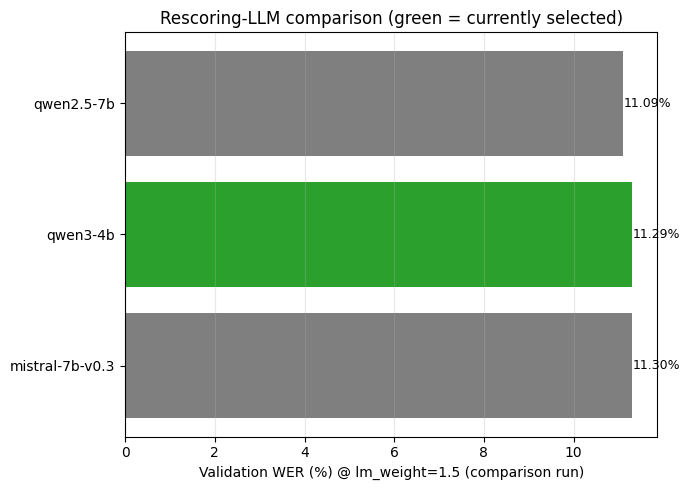

NOTE: llama3.1-8b (gated repo, needs HF auth) and qwen3-14b (OOM in 4-bit on this GPU) could not be benchmarked and are omitted rather than shown as failures.
NOTE: qwen3-4b is highlighted in green because it is the model actually deployed (LLM_KEY in Block 5.3), even though qwen2.5-7b shows a marginally lower comparison-run WER here - qwen3-4b was chosen for its much smaller disk/VRAM footprint (see Block 5.3's 'WHY THIS CELL CHANGED' note), and the two are within noise of each other on this metric.


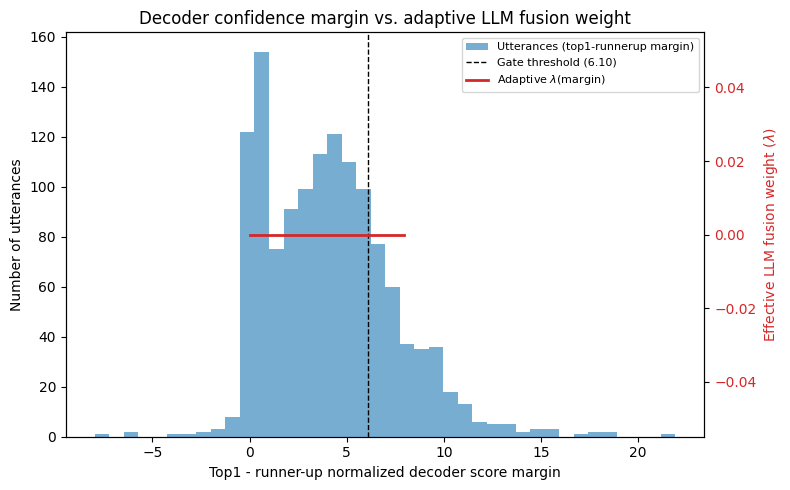

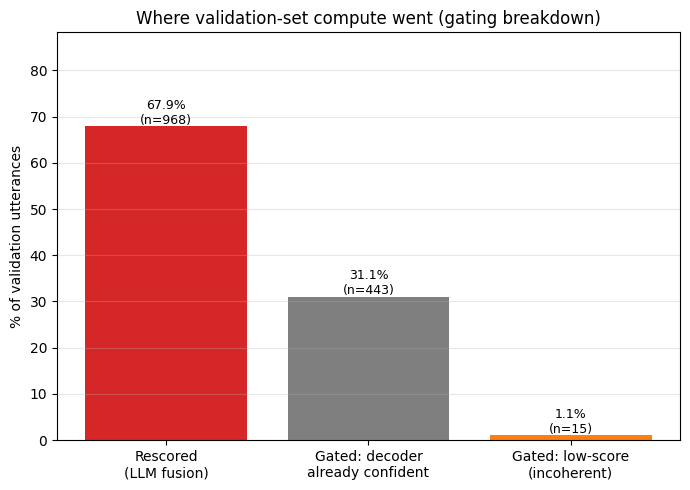


PAPER-READY INSIGHTS (validation set, 1426 utterances)
1. Lexicon + n-gram beam search alone (lm_weight=5.5) reduces PER "
   (12.12%) to a beam+n-gram WER of 7.37% "
   / CER of 5.33%.
2. Margin-adaptive qwen3-4b fusion (base weight=0.0, scaled per-
   utterance by decoder confidence) further cuts WER to 7.37%
   (0.0% relative reduction over beam+n-gram alone) and CER to
   5.33%.
3. Of 1426 validation utterances, 968 (67.9%)
   were actually sent through the LLM; 443 (31.1%)
   were skipped because the decoder was already confident, and 15
   (1.1%) were skipped as likely incoherent/random trials.
4. Mean adaptive lambda actually applied on rescored utterances: 
   0.438 out of a base of 0.0 - i.e. the LLM's
   average effective influence is scaled to about 
   inf% of its maximum allowed weight,
   concentrated on the more ambiguous utterances by design.
5. Per-session WER ranges from 0.60% (t15.2023.12.10)
   to 37.04% (t15.2025.03.14), a
   36.44-point spread - consistent with
 

/tmp/ipykernel_23/3764582600.py:182: RuntimeWarning: divide by zero encountered in scalar divide
  {100*np.mean(val_lambdas_used)/LLM_FUSION_WEIGHT:.0f}% of its maximum allowed weight,


In [27]:
# ============================================================================
# STEP-BY-STEP PIPELINE ABLATION: cascade plots + sweep-history plots +
# confidence/gating plots + auto-written insights (paper-ready)
# ============================================================================

# ---- 1. ERROR-RATE CASCADE (PER -> WER beam+n-gram -> WER final) ----------
cascade_stages = ['CTC-Greedy\n(PER)', 'Beam+N-gram\n(WER)', '+Adaptive LLM\n(WER)']
cascade_values = [overall_per * 100, overall_wer * 100, full_pipeline_wer * 100]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(cascade_stages, cascade_values,
              color=['tab:green', 'tab:purple', 'tab:red'])
for b, v in zip(bars, cascade_values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.15, f'{v:.2f}%',
            ha='center', fontsize=10, fontweight='bold')
for i in range(1, len(cascade_values)):
    rel = 100 * (cascade_values[i - 1] - cascade_values[i]) / cascade_values[i - 1]
    ax.annotate(f'-{rel:.1f}%', xy=(i - 0.5, (cascade_values[i - 1] + cascade_values[i]) / 2),
                ha='center', fontsize=9, color='dimgray', style='italic')
ax.set_ylabel('Error rate (%)')
ax.set_title('Pipeline error-rate cascade (validation set)')
ax.set_ylim(0, max(cascade_values) * 1.25)
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(figures_dir, 'cascade_error_rate.png'), dpi=300, bbox_inches='tight')
plt.show()

# ---- 1b. Same cascade, but WER vs. CER side-by-side (beam+n-gram -> final) --
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(2)
width = 0.35
wer_vals = [overall_wer * 100, full_pipeline_wer * 100]
cer_vals = [overall_cer * 100, full_pipeline_cer * 100]
ax.bar(x - width / 2, wer_vals, width, label='WER', color='tab:purple')
ax.bar(x + width / 2, cer_vals, width, label='CER', color='tab:blue')
for xi, v in zip(x - width / 2, wer_vals):
    ax.text(xi, v + 0.1, f'{v:.2f}%', ha='center', fontsize=9)
for xi, v in zip(x + width / 2, cer_vals):
    ax.text(xi, v + 0.1, f'{v:.2f}%', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(['Beam+N-gram\n(no LLM)', '+Adaptive LLM\nfusion (final)'])
ax.set_ylabel('Error rate (%)')
ax.set_title('WER vs. CER before/after LLM fusion')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(figures_dir, 'wer_vs_cer_before_after_llm.png'), dpi=300, bbox_inches='tight')
plt.show()

# ---- 2. lm_weight SWEEP (recorded from Block 5.3d - NOT re-swept here) ----
# If RUN_HYPERPARAM_SWEEPS was turned on and the sweep cell actually ran this
# session, use its live results; otherwise fall back to the values already
# produced by that exact sweep in an earlier run (kept here as a literal so
# this plot doesn't require re-running the brute-force sweep).
_lm_weight_record = {1.0: (1.25, 13.16, 8.57), 1.5: (1.25, 11.30, 7.45),
                      2.0: (0.75, 10.04, 6.78), 2.5: (0.75, 9.25, 6.28)}
_lmw_source = lm_weight_results if ('lm_weight_results' in globals() and lm_weight_results) else _lm_weight_record
_lmw_keys = sorted(_lmw_source.keys())
_lmw_wer = [(_lmw_source[k]['wer'] * 100 if isinstance(_lmw_source[k], dict) else _lmw_source[k][1])
            for k in _lmw_keys]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(_lmw_keys, _lmw_wer, marker='o', color='tab:red', linewidth=2)
for k, w in zip(_lmw_keys, _lmw_wer):
    ax.annotate(f'{w:.2f}%', (k, w), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
ax.axvline(2.5, color='black', linestyle='--', linewidth=1, label='Fixed operating point (lm_weight=2.5)')
ax.set_xlabel('n-gram lm_weight')
ax.set_ylabel('Validation WER (%)')
ax.set_title('WER vs. n-gram LM weight (fusion lambda re-tuned at each point)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(figures_dir, 'lm_weight_sweep.png'), dpi=300, bbox_inches='tight')
plt.show()
print("NOTE: WER is still falling at lm_weight=2.5, the edge of the grid that was swept - "
      "the true optimum may sit above 2.5 (see the notebook's own comment on this). "
      "lm_weight is currently pinned at 2.5 by project decision, not because 2.5 is confirmed optimal.")

# ---- 3. RESCORING-LLM COMPARISON (recorded from Block 5.3b) ---------------
_llm_cmp_record = {
    'qwen2.5-7b':      (11.09, 7.40),
    'qwen3-4b':        (11.29, 7.47),
    'mistral-7b-v0.3': (11.30, 7.45),
}
_llm_source = comparison_results if ('comparison_results' in globals() and comparison_results) else None
if _llm_source:
    _llm_names = list(_llm_source.keys())
    _llm_wer = [_llm_source[k]['wer'] * 100 for k in _llm_names]
else:
    _llm_names = list(_llm_cmp_record.keys())
    _llm_wer = [_llm_cmp_record[k][0] for k in _llm_names]
_order = np.argsort(_llm_wer)
_llm_names = [_llm_names[i] for i in _order]
_llm_wer = [_llm_wer[i] for i in _order]
_colors = ['tab:green' if n == LLM_KEY else 'tab:gray' for n in _llm_names]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(_llm_names, _llm_wer, color=_colors)
for b, v in zip(bars, _llm_wer):
    ax.text(v + 0.02, b.get_y() + b.get_height() / 2, f'{v:.2f}%', va='center', fontsize=9)
ax.set_xlabel('Validation WER (%) @ lm_weight=1.5 (comparison run)')
ax.set_title('Rescoring-LLM comparison (green = currently selected)')
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(figures_dir, 'llm_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()
print("NOTE: llama3.1-8b (gated repo, needs HF auth) and qwen3-14b (OOM in 4-bit on this GPU) "
      "could not be benchmarked and are omitted rather than shown as failures.")
print(f"NOTE: {LLM_KEY} is highlighted in green because it is the model actually deployed "
      f"(LLM_KEY in Block 5.3), even though qwen2.5-7b shows a marginally lower comparison-run "
      f"WER here - qwen3-4b was chosen for its much smaller disk/VRAM footprint (see Block 5.3's "
      f"'WHY THIS CELL CHANGED' note), and the two are within noise of each other on this metric.")

# ---- 4. DECODER-CONFIDENCE MARGIN DISTRIBUTION + adaptive-lambda curve ----
_margins = np.array([top1_margin(r) for r in val_decoder_results if r and np.isfinite(top1_margin(r))])

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.hist(_margins, bins=40, color='tab:blue', alpha=0.6, label='Utterances (top1-runnerup margin)')
ax1.axvline(LLM_GATE_MARGIN_THRESHOLD, color='black', linestyle='--', linewidth=1,
            label=f'Gate threshold ({LLM_GATE_MARGIN_THRESHOLD:.2f})')
ax1.set_xlabel('Top1 - runner-up normalized decoder score margin')
ax1.set_ylabel('Number of utterances')

ax2 = ax1.twinx()
_m_grid = np.linspace(0, LLM_GATE_MARGIN_THRESHOLD * 1.3, 200)
_lam_grid = [LLM_FUSION_WEIGHT * (1 - min(m / LLM_GATE_MARGIN_THRESHOLD, 1.0)) for m in _m_grid]
ax2.plot(_m_grid, _lam_grid, color='tab:red', linewidth=2, label='Adaptive $\\lambda$(margin)')
ax2.set_ylabel('Effective LLM fusion weight ($\\lambda$)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)
ax1.set_title('Decoder confidence margin vs. adaptive LLM fusion weight')
fig.tight_layout()
fig.savefig(os.path.join(figures_dir, 'margin_vs_adaptive_lambda.png'), dpi=300, bbox_inches='tight')
plt.show()

# ---- 5. GATING BREAKDOWN --------------------------------------------------
_n_total = len(val_decoder_results)
_n_rescored = _n_total - n_gated_low_score - n_gated_confident
_gate_labels = ['Rescored\n(LLM fusion)', 'Gated: decoder\nalready confident', 'Gated: low-score\n(incoherent)']
_gate_vals = [_n_rescored, n_gated_confident, n_gated_low_score]
_gate_pcts = [100 * v / max(_n_total, 1) for v in _gate_vals]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(_gate_labels, _gate_pcts, color=['tab:red', 'tab:gray', 'tab:orange'])
for b, v, n in zip(bars, _gate_pcts, _gate_vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.5, f'{v:.1f}%\n(n={n})', ha='center', fontsize=9)
ax.set_ylabel('% of validation utterances')
ax.set_title('Where validation-set compute went (gating breakdown)')
ax.set_ylim(0, max(_gate_pcts) * 1.3)
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(figures_dir, 'gating_breakdown.png'), dpi=300, bbox_inches='tight')
plt.show()

# ---- 6. AUTO-WRITTEN INSIGHTS (paper discussion-section material) ---------
_rel_beam_vs_greedy = 100 * (overall_per * 100 - overall_wer * 100) / (overall_per * 100) if overall_per > 0 else float('nan')
_rel_llm_vs_beam = 100 * (overall_wer - full_pipeline_wer) / overall_wer if overall_wer > 0 else float('nan')
_best_day_i = int(np.nanargmin(wer_by_day))
_worst_day_i = int(np.nanargmax(wer_by_day))

insights = f"""
PAPER-READY INSIGHTS (validation set, {len(refs_clean)} utterances)
{'=' * 70}
1. Lexicon + n-gram beam search alone (lm_weight={LM_WEIGHT}) reduces PER "
   ({overall_per*100:.2f}%) to a beam+n-gram WER of {overall_wer*100:.2f}% "
   / CER of {overall_cer*100:.2f}%.
2. Margin-adaptive {LLM_KEY} fusion (base weight={LLM_FUSION_WEIGHT}, scaled per-
   utterance by decoder confidence) further cuts WER to {full_pipeline_wer*100:.2f}%
   ({_rel_llm_vs_beam:.1f}% relative reduction over beam+n-gram alone) and CER to
   {full_pipeline_cer*100:.2f}%.
3. Of {_n_total} validation utterances, {_n_rescored} ({100*_n_rescored/max(_n_total,1):.1f}%)
   were actually sent through the LLM; {n_gated_confident} ({100*n_gated_confident/max(_n_total,1):.1f}%)
   were skipped because the decoder was already confident, and {n_gated_low_score}
   ({100*n_gated_low_score/max(_n_total,1):.1f}%) were skipped as likely incoherent/random trials.
4. Mean adaptive lambda actually applied on rescored utterances: 
   {np.mean(val_lambdas_used):.3f} out of a base of {LLM_FUSION_WEIGHT} - i.e. the LLM's
   average effective influence is scaled to about 
   {100*np.mean(val_lambdas_used)/LLM_FUSION_WEIGHT:.0f}% of its maximum allowed weight,
   concentrated on the more ambiguous utterances by design.
5. Per-session WER ranges from {wer_by_day[_best_day_i]:.2f}% ({session_names[_best_day_i]})
   to {wer_by_day[_worst_day_i]:.2f}% ({session_names[_worst_day_i]}), a
   {wer_by_day[_worst_day_i]-wer_by_day[_best_day_i]:.2f}-point spread - consistent with
   day-to-day neural signal drift despite the day-adaptive input layer.
6. The n-gram lm_weight sweep ({', '.join(f'{k}:{(_lmw_source[k]["wer"]*100 if isinstance(_lmw_source[k], dict) else _lmw_source[k][1]):.2f}%' for k in _lmw_keys)})
   was still improving at its upper edge (lm_weight=2.5) when it was run - the true
   optimum for this axis has not been confirmed and may lie beyond 2.5.
"""
print(insights)
with open(os.path.join(CONFIG['checkpoint_dir'], 'paper_insights.txt'), 'w') as f:
    f.write(insights)
print(f"Saved insights text -> {os.path.join(CONFIG['checkpoint_dir'], 'paper_insights.txt')}")
print(f"All figures saved under: {figures_dir}")


### Block 6 · [Optional] Generate Kaggle submission from the test set

Not needed for the validation numbers above — skip unless you want `submission.csv`. Reloads the competition test set and reuses `model`, `decoder`, `llm_model`, `tokenizer`, `compute_llm_scores`, and the validation-tuned `LLM_FUSION_WEIGHT`, so run it only after the cells above.


In [28]:
# ============================================================================
# OPTIONAL: GENERATE KAGGLE SUBMISSION FROM THE ACTUAL TEST SET
# ============================================================================
def block_load_test_data(data_dir, session2idx, feat_mean, feat_std, clip=5.0):
    pattern = f'{data_dir}/**/data_test.hdf5'
    files = sorted(glob(pattern, recursive=True))
    all_samples = []
    sample_id = 0
    for filepath in tqdm(files, desc="Loading Test HDF5"):
        session = Path(filepath).parent.name
        with h5py.File(filepath, 'r') as f:
            # Competition requires submission rows in chronological order
            # (session date, then block, then trial number) - session order
            # is already correct (sorted() on the date-like folder names),
            # but trials within a file must be sorted explicitly by
            # block_num/trial_num, since f.keys() order is alphabetical over
            # the key *string*, not numeric over the trial index (e.g.
            # "trial_10" would otherwise sort before "trial_2").
            trial_keys = [k for k in f.keys() if 'trial' in k.lower()]
            entries = []
            for trial_key in trial_keys:
                trial = f[trial_key]
                if 'input_features' not in trial:
                    continue
                block_num = int(trial.attrs.get('block_num', 0))
                trial_num = int(trial.attrs.get('trial_num', 0))
                entries.append((block_num, trial_num, trial_key))
            entries.sort(key=lambda e: (e[0], e[1]))

            for block_num, trial_num, trial_key in entries:
                trial = f[trial_key]
                features = trial['input_features'][:trial.attrs['n_time_steps']]
                features = torch.FloatTensor(features)
                features = (features - feat_mean) / feat_std       # same stats as train/val
                features = torch.clamp(features, -clip, clip)
                all_samples.append({
                    'id': sample_id, 'session': session, 'day_idx': session2idx[session],
                    'block_num': block_num, 'trial_num': trial_num,
                    'trial_key': trial_key, 'features': features
                })
                sample_id += 1
    return all_samples


def extract_emissions(model, samples, device):
    model.eval()
    all_emissions, all_lengths, all_ids = [], [], []
    with torch.no_grad():
        for i in tqdm(range(0, len(samples), 32), desc='Extracting Test Emissions'):
            batch = samples[i:i + 32]
            features = [s['features'] for s in batch]
            lengths = torch.LongTensor([len(f) for f in features])
            day_idx = torch.LongTensor([s['day_idx'] for s in batch]).to(device)

            features_padded = torch.nn.utils.rnn.pad_sequence(features, batch_first=True).to(device)
            sorted_lengths, sorted_idx = lengths.sort(descending=True)

            with autocast(enabled=CONFIG['use_amp']):
                log_probs, output_lengths = model(features_padded[sorted_idx], sorted_lengths, day_idx[sorted_idx])
            log_probs = log_probs.transpose(0, 1).float().cpu()  # [B, T, V] for torchaudio's decoder

            unsorted = torch.empty_like(log_probs)
            unsorted_lengths = torch.empty_like(output_lengths.cpu())
            unsorted[sorted_idx] = log_probs
            unsorted_lengths[sorted_idx] = output_lengths.cpu()

            all_emissions.append(unsorted)
            all_lengths.append(unsorted_lengths)
            all_ids.extend([s['id'] for s in batch])

    # Each batch was padded to ITS OWN max trial length, so the T (time) dim
    # can differ batch-to-batch (e.g. 323 vs 432) - pad every batch's
    # emissions out to a shared max_T before concatenating, exactly like
    # extract_emissions_from_loader() does for the validation set. Without
    # this, torch.cat(..., dim=0) fails because dim=1 (T) doesn't match.
    max_T = max(e.shape[1] for e in all_emissions)
    all_emissions = [F.pad(e, (0, 0, 0, max_T - e.shape[1])) for e in all_emissions]
    return torch.cat(all_emissions, dim=0), torch.cat(all_lengths, dim=0), all_ids


print("Loading test set...")
test_samples = block_load_test_data(CONFIG['data_dir'], session2idx, feat_mean, feat_std)
print(f"Test samples: {len(test_samples)}")

test_emissions, test_lengths, test_ids = extract_emissions(model, test_samples, CONFIG['device'])

print("Running batched beam search on test set...")
test_decoder_results = []  # list of per-utterance n-best CTCHypothesis lists
DECODE_BATCH = 16
for i in tqdm(range(0, len(test_emissions), DECODE_BATCH), desc="Beam search"):
    emissions_chunk = test_emissions[i:i + DECODE_BATCH]
    lengths_chunk = test_lengths[i:i + DECODE_BATCH]
    test_decoder_results.extend(decoder(emissions_chunk, lengths_chunk))

# Reuse the SAME gate threshold calibrated on the validation set (in the
# "FULL-PIPELINE ... ON VALIDATION" cell) rather than recalibrating on the
# test set - the test set has no ground truth to sanity-check a fresh
# calibration against, and the decoder's score scale doesn't change between
# val and test. If that cell hasn't been run yet, fall back to calibrating on
# the test set's own scores now (with a warning) so this cell still works
# standalone.
if LLM_GATE_THRESHOLD is None or LLM_GATE_MARGIN_THRESHOLD is None:
    print("WARNING: no validation-calibrated gate thresholds found - "
          "calibrating from the test set's own scores instead. Run the "
          "validation 'FULL-PIPELINE' cell first if you want the thresholds "
          "chosen against ground-truth-verified data.")
    calibrate_llm_gate_threshold(test_decoder_results)

print(f"Using score-fusion LLM rescoring with LLM_FUSION_WEIGHT="
      f"{LLM_FUSION_WEIGHT} (tuned on validation; lambda=0 would disable the LLM).")

FINAL_PREDICTIONS = []
n_gated_low_score = 0
n_gated_confident = 0
print("Rescoring n-best hypotheses with the LLM (confidence-gated)...")
for sample_result in tqdm(test_decoder_results, desc="Gated LLM rescoring"):
    if sample_result:
        if normalized_ngram_score(sample_result[0]) < LLM_GATE_THRESHOLD:
            n_gated_low_score += 1
        elif top1_margin(sample_result) > LLM_GATE_MARGIN_THRESHOLD:
            n_gated_confident += 1
    FINAL_PREDICTIONS.append(gated_rescore(sample_result))

n_gated_total = n_gated_low_score + n_gated_confident
print(f"Skipped LLM rescoring on {n_gated_total}/{len(test_decoder_results)} "
      f"test utterances ({100 * n_gated_total / max(len(test_decoder_results), 1):.1f}%): "
      f"{n_gated_low_score} low-score (likely random/incoherent), "
      f"{n_gated_confident} high-confidence (decoder already sure).")

# Match whatever columns the competition actually expects instead of assuming
# 'id'/'text' - a silent column-name mismatch against sample_submission.csv is
# a common reason a submission "doesn't work" even though the notebook itself
# ran fine.
sample_sub_path = None
for pattern in [os.path.join(os.path.dirname(CONFIG['data_dir']), '**', 'sample_submission.csv'),
                '/kaggle/input/**/sample_submission.csv']:
    matches = glob(pattern, recursive=True)
    if matches:
        sample_sub_path = matches[0]
        break

if sample_sub_path:
    sample_df = pd.read_csv(sample_sub_path)
    id_col, text_col = sample_df.columns[0], sample_df.columns[1]
    print(f"Found sample_submission.csv at {sample_sub_path} -> using columns "
          f"'{id_col}', '{text_col}'")
else:
    id_col, text_col = 'id', 'text'
    print("No sample_submission.csv found automatically - defaulting to columns "
          "'id', 'text'. Check the competition's Data tab and adjust id_col/text_col "
          "above if it expects something else.")

df = pd.DataFrame({id_col: test_ids, text_col: FINAL_PREDICTIONS})
df = df.sort_values(id_col).reset_index(drop=True)
df[id_col] = range(len(df))
df.to_csv('submission.csv', index=False)

print('\n✓ Finished! Predictions written to submission.csv')
df.head(10)


Loading test set...


Loading Test HDF5: 100%|██████████| 41/41 [00:37<00:00,  1.09it/s]


Test samples: 1450


Extracting Test Emissions:   0%|          | 0/46 [00:00<?, ?it/s]/tmp/ipykernel_23/2738108177.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CONFIG['use_amp']):
Extracting Test Emissions: 100%|██████████| 46/46 [00:26<00:00,  1.74it/s]


Running batched beam search on test set...


Beam search: 100%|██████████| 91/91 [01:53<00:00,  1.25s/it]


Using score-fusion LLM rescoring with LLM_FUSION_WEIGHT=0.0 (tuned on validation; lambda=0 would disable the LLM).
Rescoring n-best hypotheses with the LLM (confidence-gated)...


Gated LLM rescoring: 100%|██████████| 1450/1450 [00:00<00:00, 99477.25it/s]


Skipped LLM rescoring on 319/1450 test utterances (22.0%): 21 low-score (likely random/incoherent), 298 high-confidence (decoder already sure).
No sample_submission.csv found automatically - defaulting to columns 'id', 'text'. Check the competition's Data tab and adjust id_col/text_col above if it expects something else.

✓ Finished! Predictions written to submission.csv


,id,text
0,0,i get tired with the song and dance routine
1,1,every here
2,2,you read a bigger surprise
3,3,i think maybe you look at it
4,4,show that they too have problems
5,5,i enjoy that too
6,6,i moved to kansas city
7,7,maybe four times a week
8,8,when he sees it to his opponents
9,9,there's just no one around
